## __<span style= "color: #87CEEB;"> Feed Forward ANN </span>__

<img src="Images/dmytro-demidko-eBWzFKahEaU-unsplash%20(1).jpg" width="5000"/>

#### <span style = "color: #9fcddfff;"> **About This Project** </span>

- **Core Objective:** Build a binary classifier (feed-forward neural network implemented in Keras/TensorFlow) to predict whether a customer will subscribe to a term deposit.

- **Data Context:** [Bank marketing dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing) (UCI Machine Learning Repository). The dataset contains customer demographics, contact information, campaign details, and the target variable indicating subscription.

- **Approach:** Perform data cleaning, exploratory data analysis, feature engineering, and train a feed-forward ANN. Evaluate performance using accuracy, precision, recall, and AUC on a holdout test set. This architecture has the ability to learn complex, non-linear relationships within the customer data _(which as we may see later on- there might not be a linear relationship between the input data and the prediction of a customer's sucbscription)_.
    - This is a school task requiring only the `Layers` and the `Neurons` hyperparemters to be changed. The rest left constant.
    
    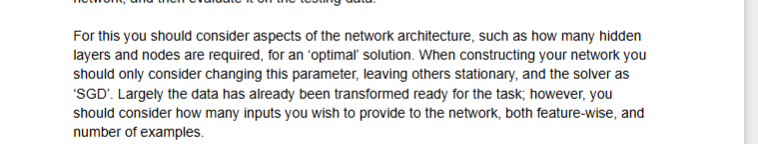

---

## <span style = "color: #9fcddfff;"> **Details of the Dataset** </span>


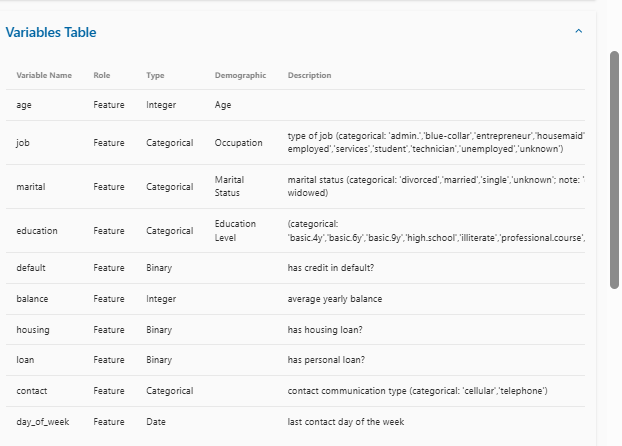 

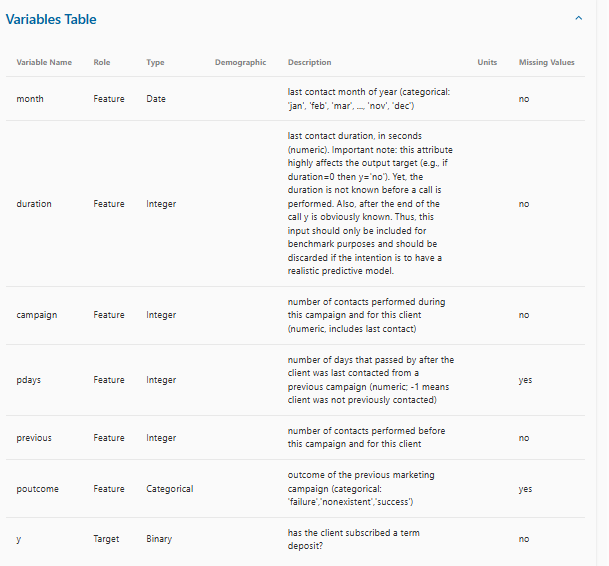

---

#### __<span style= "color: #92bbcaff;"> Import Libraries and Dataset </span>__ 

In [1]:
#libraies for preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#library for datasplit 
from sklearn.model_selection import train_test_split
#libraries for scaling
from sklearn.preprocessing import RobustScaler, StandardScaler


#libraries needed for the feedforward nodel
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
#Hypertuning
from scikeras.wrappers import KerasClassifier
# GridSearchCV comes from sklearn, not scikeras.model_selection
from sklearn.model_selection import GridSearchCV, train_test_split

#Evaluative Metrics
from sklearn.metrics import accuracy_score, recall_score, precision_score, precision_recall_curve, f1_score, ConfusionMatrixDisplay, confusion_matrix, balanced_accuracy_score


In [2]:
df = pd.read_csv(r'Bank.csv')

In [3]:
df.head()

,age,marital,education,default,balance,housing,loan,contact,duration,campaign,pdays,previous,poutcome,y
0,33,1,2,no,882,no,no,1,39,1,151,3,0,no
1,42,0,1,no,-247,yes,yes,1,519,1,166,1,2,yes
2,33,1,1,no,3444,yes,no,1,144,1,91,4,0,yes
3,36,1,2,no,2415,yes,no,1,73,1,86,4,2,no
4,36,1,2,no,0,yes,no,1,140,1,143,3,0,yes


#### __<span style= "color: #92bbcaff;"> Data Exploration </span>__ 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7842 entries, 0 to 7841
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        7842 non-null   int64 
 1   marital    7842 non-null   int64 
 2   education  7842 non-null   int64 
 3   default    7842 non-null   object
 4   balance    7842 non-null   int64 
 5   housing    7842 non-null   object
 6   loan       7842 non-null   object
 7   contact    7842 non-null   int64 
 8   duration   7842 non-null   int64 
 9   campaign   7842 non-null   int64 
 10  pdays      7842 non-null   int64 
 11  previous   7842 non-null   int64 
 12  poutcome   7842 non-null   int64 
 13  y          7842 non-null   object
dtypes: int64(10), object(4)
memory usage: 857.8+ KB


_This confirms no null value, the shape to be `[7842,10]`_

In [5]:
df.shape

(7842, 14)

In [6]:
def feature_values(df, dropna=True):

    """ 
    This functiion gives a quick glanmcfe at the unique values and number of unique values (with a default settings to 
    drop all null values
     """
    row =[]
    for col in df.columns:
        unique = df[col].dropna().unique() if dropna else df[col].unique()
        n_unique = df[col].nunique(dropna=dropna)
        row.append({"Features": col, "Number of Unique Values": n_unique,"Unique Values": unique})
    return pd.DataFrame(row)
      

In [7]:
feature_values(df)

,Features,Number of Unique Values,Unique Values
0,age,70,"[33, 42, 36, 44, 26, 51, 30, 34, 49, 47, 40, 3..."
1,marital,3,"[1, 0, 2]"
2,education,3,"[2, 1, 0]"
3,default,2,"[no, yes]"
4,balance,3090,"[882, -247, 3444, 2415, 0, 1324, 172, 3132, 10..."
5,housing,2,"[no, yes]"
6,loan,2,"[no, yes]"
7,contact,2,"[1, 0]"
8,duration,973,"[39, 519, 144, 73, 140, 119, 21, 449, 175, 86,..."
9,campaign,16,"[1, 2, 3, 5, 4, 6, 7, 8, 9, 11, 10, 12, 14, 15..."


#### __<span style= "color: #30bbafff;"> Comments </span>__

<span style= "color: #30bbafff;"> Feature Selection </span>:

The folloiwing features will be deleted because:
-  <span style= "color: #30bbafff;"> Contact </span>: 
From the variable data/table, the unique values of the contact feature is 1 and 0 as seen in the diagram below:
Which will be the case if customers are contacted via cellular or telephone (this means that the method of communication holds no weight in determining whether a customer will make a term deposit or not). Hence, it'd be deleted.

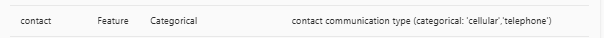


- <span style= "color: #30bbafff ;"> Duration </span>: 
This will also be deleted; as advised, this can only be known after a call has been placed, by which time the y label (if a customer has a term deposit) will already be known, regardless. So, it is not relevant to a predictive model of deciding if a customer will have a term deposit before even contacting them. This is a post-contact variable that leaks information about the outcome (it is recorded only after contact), so dropping it will avoid target leakage.

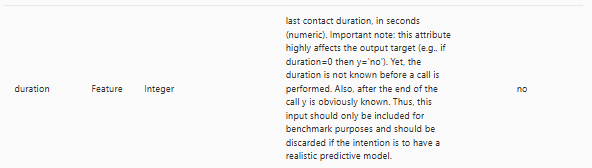


- <span style= "color: #30bbafff ;"> Marital </span>: 
The unique values here are 0,1 and 2. Which are not quite indicative of what the unique values of the metatdata for `Marital status`. Much more, this is a loose feature in determining. Where income, number iof dependants could have held more weight.

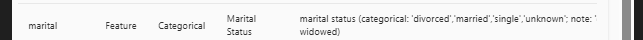


- <span style= "color: #30bbafff ;"> Education </span>: The indexed numbers are 0,1 and 2. Which aren't clearly indicative of the classed categories under the feature `eductaion`. Uneducated people may be successful in brown-collar jobs and still have the caapcity nto mkake tions of money from a non 9-5 job, as much as an educated executive. This is co0nmsidering the current trend and increasing non-linear relationship between education and wealth in today's age.

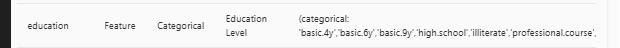




- <span style= "color: #30bbafff ;"> Null Values </span>: There are no null values to address.

## __<span style= "color: #92bbcaff;"> Preprocessing </span>__ 

__Delete Irrelevant Features__

In [8]:
df.columns

Index(['age', 'marital', 'education', 'default', 'balance', 'housing', 'loan',
       'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome',
       'y'],
      dtype='object')

In [9]:
to_del = ['marital', 'education', 'contact', 'duration']
df.drop(to_del, inplace=True, axis=1)
df.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

__Encode Strings__

In [10]:
feature_values(df)

,Features,Number of Unique Values,Unique Values
0,age,70,"[33, 42, 36, 44, 26, 51, 30, 34, 49, 47, 40, 3..."
1,default,2,"[no, yes]"
2,balance,3090,"[882, -247, 3444, 2415, 0, 1324, 172, 3132, 10..."
3,housing,2,"[no, yes]"
4,loan,2,"[no, yes]"
5,campaign,16,"[1, 2, 3, 5, 4, 6, 7, 8, 9, 11, 10, 12, 14, 15..."
6,pdays,527,"[151, 166, 91, 86, 143, 89, 140, 176, 174, 167..."
7,previous,39,"[3, 1, 4, 2, 16, 6, 5, 10, 12, 7, 18, 9, 8, 11..."
8,poutcome,3,"[0, 2, 1]"
9,y,2,"[no, yes]"


In [11]:
print(f"The maximum age is {df['age'].max()}")
print(f"The minimum age is {df['age'].min()}")

The maximum age is 89
The minimum age is 18


In [12]:
cols = ['default', 'housing', 'loan', 'y']
df[cols] = df[cols].replace({"yes": 1, "no": 0})

C:\Users\kojus\AppData\Local\Temp\ipykernel_11368\1974972438.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols] = df[cols].replace({"yes": 1, "no": 0})


In [13]:
df

,age,default,balance,housing,loan,campaign,pdays,previous,poutcome,y
0,33,0,882,0,0,1,151,3,0,0
1,42,0,-247,1,1,1,166,1,2,1
2,33,0,3444,1,0,1,91,4,0,1
3,36,0,2415,1,0,1,86,4,2,0
4,36,0,0,1,0,1,143,3,0,1
...,...,...,...,...,...,...,...,...,...,...
7837,34,0,1475,1,0,3,530,12,2,0
7838,53,0,583,0,0,1,184,4,1,1
7839,73,0,2850,0,0,1,40,8,0,1
7840,72,0,5715,0,0,5,184,3,1,1


In [14]:
df.campaign.value_counts()

campaign
1     3784
2     2180
3      870
4      406
5      247
6      153
7       93
8       52
9       24
11      12
10      10
12       7
14       1
15       1
13       1
16       1
Name: count, dtype: int64

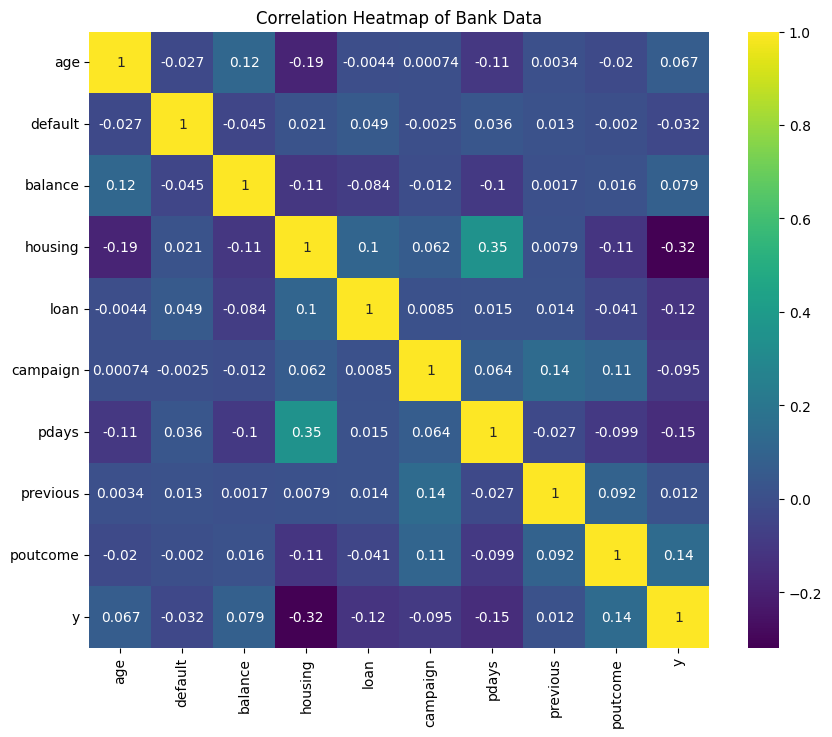

In [15]:
# To plot a heatmap of the correlation matrix for the dataframe:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='viridis', annot=True)
plt.title('Correlation Heatmap of Bank Data')
plt.show()

From the above:
- The probability of subscribiing to a `term_deposit` correlated to the `age` is not a strong correlation. A neglible correlation- almost weak.
- The highest `poutcome` has the highest correlation to the `term deposit`. Signalling that the outcome of previous campaigns (0 for failure and 1 for success) has a direct correlation on infleuncing the possibility of a customer subscribing to the `term-deposit`.
- The `Campaign` has the highest inverse relationship with the probablity of a customer subscribing to `term deposit`. This isnt far-reached as from the details; it could be that:
    - customers get ticked off by the frequency of campaign Ads that they lose interest in general. If the Ads were not spammed- porbbaly that could have been a different case.
- Much as `poutcome` has the highest correlation means that campaigns are effective- as long as they do not come across as spamming.

__Split Data__

In [16]:
df.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [17]:
df.shape

(7842, 10)

In [18]:
x = df.drop('y', axis=1).copy()
y = df['y'].copy()

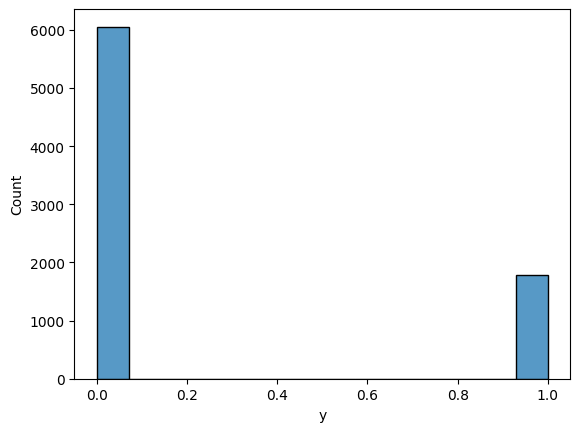

In [19]:
sns.histplot(y);

_This confirms if the categorical label is imbalanced_

In [20]:
#because the y_label is imbalanced, stratified will used to ensure equal percenatge distribution of the data in both the train and test data

X_temp, X_test, y_temp, y_test = train_test_split(
    x, y, 
    test_size=0.10, 
    random_state=20,
    stratify=y,
    shuffle=True
    )

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.111, 
    random_state=42,
    stratify=y_temp,
    shuffle=True
    )

In [21]:

original_size = df.shape[0]
print(f"The original data_size is {original_size}")

temp_size = original_size * 0.90

train_size = temp_size * 0.90
print(f"The training sample size is {train_size/original_size:.1%}")

val_size = temp_size * 0.111
print(f"The validation sample size is {val_size/original_size:.1%}")

test_size = original_size * 0.10
print(f"The test sample size is {test_size/original_size:.1%}")

The original data_size is 7842
The training sample size is 81.0%
The validation sample size is 10.0%
The test sample size is 10.0%


In [22]:
val_tobe_10_percent = 0.10/0.90

#0.10 is the intended percentage
#0.90 is the total data or temp sample size the 10% is to be gotten from

_Quick Outlier Check to confirm which scaler will be used to ensure the range of the numbers are all on the same scale_

In [23]:
# compute outlier counts per-column on training data
num_train = X_train.select_dtypes(include=[np.number])
q1 = num_train.quantile(0.25)
q3 = num_train.quantile(0.75)

iqr = q3 - q1

upper_bound = q3 + (1.5 * iqr)
lower_bound = q1 - (1.5 * iqr)

outliers = (num_train < lower_bound) | (num_train > upper_bound)
print(outliers.sum().sort_values(ascending=False))

loan        860
campaign    804
balance     618
previous    327
age         153
default      41
pdays        19
housing       0
poutcome      0
dtype: int64


In [24]:

num_of_rows_with_outliers = outliers.any(axis=1).sum()
length = num_of_rows_with_outliers/len(num_train)

total_outlier_percent = num_of_rows_with_outliers/length

if total_outlier_percent > 0.05:
    scaler = RobustScaler()
    print("using the RobustScaler due to outliers (rows with outliers total {:.2%})".format(length))
else:
    scaler = StandardScaler()
    print("using the RobustScaler due to outliers (rows with outliers total {:.2%})".format(length))



using the RobustScaler due to outliers (rows with outliers total 37.24%)


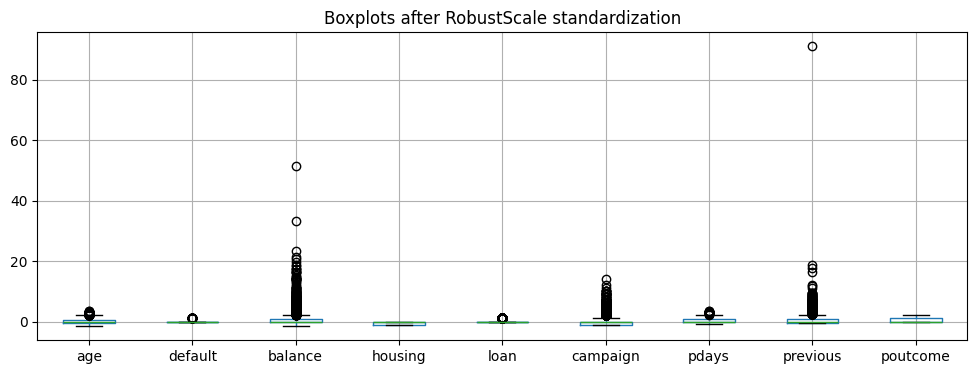

In [25]:

norm = scaler.fit_transform(num_train)
norm_df = pd.DataFrame(norm, columns=num_train.columns)

plt.figure(figsize=(12,4))
norm_df.boxplot(vert=True)
plt.title('Boxplots after RobustScale standardization')
plt.show()

__Scale X Features__

- The range of the data spreads from 0/1 to ages, up to and beyond, 32. Normalizing brings all the features on the same scale

- _Now transform and fit on the entire x_train dataset; having confirmed there are large outliers and RobustScaler is the scale to use_

In [26]:

x_train_scaled = scaler.fit_transform(X_train)
x_val_scaled = scaler.transform(X_val)
x_test_scaled = scaler.transform(X_test)

print("Scaling automatically converts the data_type to a numpy array; so there'd be no need for that step")
print(f"\nx_train data_type: {type(X_train)}")
print(f"x_train_scaled data_type: {type(x_train_scaled)}")

#the numpy conversion is sorted

Scaling automatically converts the data_type to a numpy array; so there'd be no need for that step

x_train data_type: <class 'pandas.core.frame.DataFrame'>
x_train_scaled data_type: <class 'numpy.ndarray'>


### __<span style= "color: #92bbcaff;"> Model Architectures </span>__ 

- The models architectures will use the `Sigmoid` output activation because it'd only output 1 feedback
<br>
<br>
- Throughout the model architectures that'd be explored, the `Relu` activation function and the `SGD` Optimizer will be constant (including the learning rate); the only hyperparameters that'd be updated are the `Neurons` and the `Number of Hidden Layers`
<br>
<br>
- __<span style= "color: #92bbcaff;"> Thought Process behind NEURON Updates </span>:__ Based on dataset scale heuristics commonly employed in practical ML, this dataset falls under the medium size. Hence, neurons [64, 32, 16] would mostly be experimented with and the depth would incremetally be expanded:
    - `Small dataset: < 1000 [Neurons: {32, 16, 8}]`
    - `Medium dataset: 1000 - 10000 [Neurons: {64, 32, 16}]`
    - `Large dataset: 10000 - 100000 [Neurons: {128, 64, 32, 16}]`
    - `Very Large dataset: > 100000[Neurons: {256, 128, 64, 32}]`
<br>    _So, the neurons: **[64, 32, 16]** will firstly, and mostly, be explored with across the model architectural types_
<br>
<br>

- __<span style= "color: #92bbcaff;"> Thought Process behind LAYER Updates </span>: Model Architectural types like__; 
    - `Single-layer`_: Shallow Network- Good for starting up the baseline model,_
    - `pyramid architecture`_: Gradually removes irrelevant details, keeps important information,_ 
    - `Constant-Width Architecture`_: It's a relatively shallow netowrk that fits the use-case and size of this data._
      - `Hourglass Architecture`,_: Learnns efficient Data Representation by removing noise while keeping important patters, and_
    - `Diamond Architecture`_:Good for complex interactions, which in our case may be due to the non-lineratity of the varables and the target label_
    <br> <br> 
    - _Only `Inverted-Pyramid Architecture`_: Not the best for simple classification Problems and for a datatset size of this_
    <br> <br> 

- __<span style= "color: #92bbcaff;"> Thought Process behind Chosen METRICS </span>:__
    - Since the prediction is being developed with the objective to predict customers who are likely to 'Term-Deposit'- which invariably contrubutes to the profit of the Bank; it'd be costly to miss any 'likely customers' who could have deposited _(FN)_, it's better to have more _(FP)_ who may eventually be convinced after a call from the team. To this end, `Recall` will be a major metric in assessing the model with the best performance or higest recall score.


In [27]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] =  '3'

In [28]:
X_train.shape

(6273, 9)

__<span style= "color: #92bbcaff;"> BASELINE MODEL </span>__ 

- __Thought process behind the basline build: According to the _`Hands-On ML with Scikit-Learn, and TensorFlow Textbook- by Aurelien Geron [Chapter 10; Fine-tuning Neural Network Hyperparamters]`_, a simpe baseline is defined by how sahllow or not-so-deep the netowrk or layer is. However, the neurons could be high signalling. As he metioned a model could have 2 layers totalling 100 neurons with an accuracy of 98%, while a model with 1 layer and having 100 neurons could have an accuracy score of 97%.__.....reference link..

In [ ]:
baseline_model_A = keras.Sequential([
    layers.InputLayer(input_shape=(9,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name='baseline_relu_64')

baseline_model_A.summary();

baseline_model_A.compile(optimizer='SGD',
                       metrics=['accuracy'],
                       loss='binary_crossentropy')

baseline_model_history_A = baseline_model_A.fit(x_train_scaled, y_train,
                                            validation_data=(x_val_scaled, y_val),
                                            epochs=100)

c:\Users\kojus\anaconda3\envs\ML_DM\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "baseline_relu_64"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705 (2.75 KB)

 Trainable params: 705 (2.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7221 - loss: 0.6081 - val_accuracy: 0.7717 - val_loss: 0.5707
Epoch 2/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7724 - loss: 0.5527 - val_accuracy: 0.7717 - val_loss: 0.5416
Epoch 3/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7724 - loss: 0.5293 - val_accuracy: 0.7717 - val_loss: 0.5237
Epoch 4/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7722 - loss: 0.5137 - val_accuracy: 0.7730 - val_loss: 0.5103
Epoch 5/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7719 - loss: 0.5026 - val_accuracy: 0.7742 - val_loss: 0.5013
Epoch 6/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7717 - loss: 0.4946 - val_accuracy: 0.7730 - val_loss: 0.4983
Epoch 7/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7722 - loss: 0.4884 - val_accuracy: 0.7781 - val_loss: 0.4886
Epoch 8/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7732 - loss: 0.4837 - val_acc

accuracy
loss
val_accuracy
val_loss
-----

Evaluative Metric
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
The Balanced Accuracy Score is 0.6878110716099542
The Recall Score is 0.4301675977653631
The F1 Score is 0.532871972318339
The Precision Score is 0.7


(array([0.22831633, 0.22860792, 0.22890026, 0.22919334, 0.22948718,
        0.22978177, 0.23007712, 0.23037323, 0.2306701 , 0.23096774,
        0.23126615, 0.23156533, 0.23186528, 0.23216602, 0.23246753,
        0.23276983, 0.23307292, 0.23337679, 0.23368146, 0.23398693,
        0.23429319, 0.23460026, 0.23490814, 0.23521682, 0.23552632,
        0.23583663, 0.23614776, 0.23645971, 0.23677249, 0.23708609,
        0.23740053, 0.2377158 , 0.23803191, 0.23834887, 0.23866667,
        0.23898531, 0.23930481, 0.23962517, 0.23994638, 0.24026846,
        0.2405914 , 0.24091521, 0.24123989, 0.24156545, 0.24189189,
        0.24221922, 0.24254743, 0.24287653, 0.24320652, 0.24353741,
        0.24386921, 0.24420191, 0.2431694 , 0.24213406, 0.24246575,
        0.24279835, 0.24313187, 0.2434663 , 0.24380165, 0.24413793,
        0.24447514, 0.24481328, 0.24515235, 0.24549237, 0.24583333,
        0.24617524, 0.24651811, 0.24686192, 0.2472067 , 0.24755245,
        0.24789916, 0.24824684, 0.24859551, 0.24

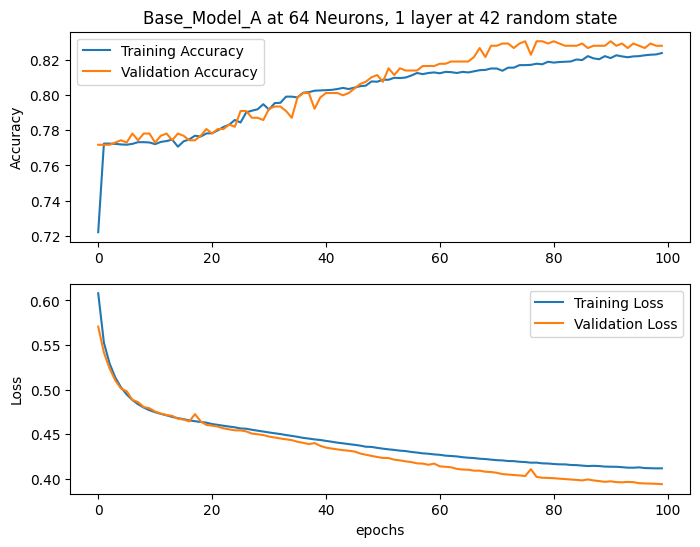

In [30]:
for key in baseline_model_history_A.history.keys():
    print(key)

fig, (ax1, ax2) = plt.subplots(2, figsize=(8, 6))

acc = baseline_model_history_A.history['accuracy']
loss = baseline_model_history_A.history['loss']

val_acc = baseline_model_history_A.history['val_accuracy']
val_loss = baseline_model_history_A.history['val_loss']

ax1.plot(acc, label='Training Accuracy')
ax1.plot(val_acc, label='Validation Accuracy')

ax2.plot(loss, label='Training Loss')
ax2.plot(val_loss, label='Validation Loss')

ax1.set_ylabel('Accuracy')
ax2.set_ylabel('Loss')
 
ax2.set_xlabel('epochs')

ax1.legend()
ax2.legend()

ax1.set_title('Base_Model_A at 64 Neurons, 1 layer at 42 random state')

print('-----')

print('\nEvaluative Metric')

y_pred_prob = baseline_model_A.predict(x_val_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)



recall_val = recall_score(y_val, y_pred)
accuracy_val = balanced_accuracy_score(y_val, y_pred)
f1_val = f1_score(y_val, y_pred)
precision_val = precision_score(y_val, y_pred)

print(f'The Balanced Accuracy Score is {accuracy_val}')
print(f'The Recall Score is {recall_val}')
print(f'The F1 Score is {f1_val}')
print(f'The Precision Score is {precision_val}')

precision_recall_curve(y_val, y_pred_prob)



25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
The Accuracy Score is 0.8278
The Recall Score is 0.4302
The F1 Score is 0.5329
The Precision Score is 0.7000


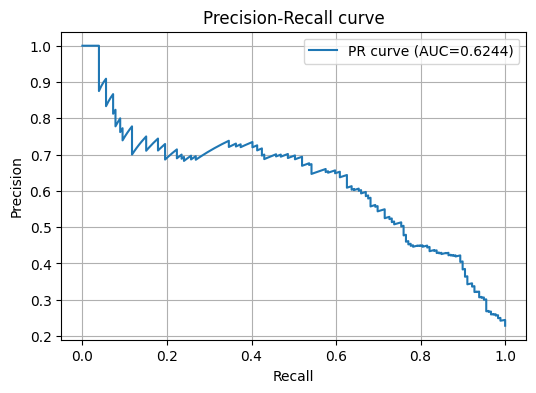

In [ ]:

from sklearn.metrics import auc

y_pred_prob = baseline_model_A.predict(x_val_scaled)
# reshape & threshold
y_pred_prob = np.asarray(y_pred_prob).reshape(-1)
if y_pred_prob.dtype.kind in 'f':
    y_pred = (y_pred_prob >= 0.5).astype(int)
else:
    y_pred = y_pred_prob.astype(int)

recall_val = recall_score(y_val, y_pred)
accuracy_val = accuracy_score(y_val, y_pred)
f1_val = f1_score(y_val, y_pred)
precision_val = precision_score(y_val, y_pred)

print(f'The Accuracy Score is {accuracy_val:.4f}')
print(f'The Recall Score is {recall_val:.4f}')
print(f'The F1 Score is {f1_val:.4f}')
print(f'The Precision Score is {precision_val:.4f}')

# Precision-Recall curve (use probabilities)
precision_vals, recall_vals, thresholds = precision_recall_curve(y_val, y_pred_prob)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(6,4))
plt.plot(recall_vals, precision_vals, label=f'PR curve (AUC={pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.legend()
plt.grid(True)
plt.show()


Text(0.5, 1.0, 'Confusion Matrix for Base_Model_B at 64 Neurons, 1 layer at 42 random state')

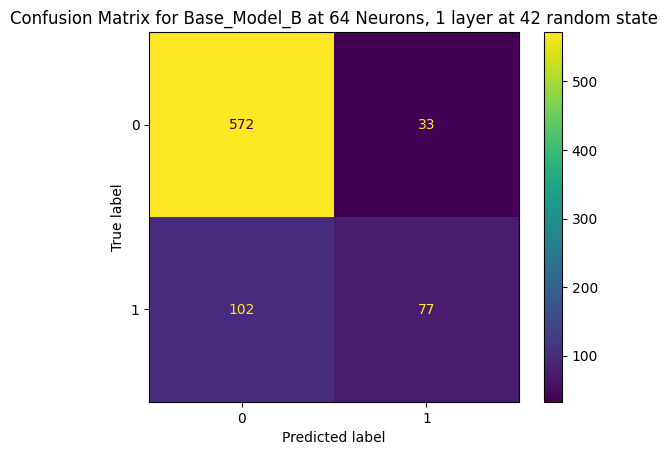

In [32]:
a  = ConfusionMatrixDisplay.from_predictions(y_val, np.round(y_pred))
plt.title('Confusion Matrix for Base_Model_B at 64 Neurons, 1 layer at 42 random state')

Text(0.5, 1.0, 'Confusion Matrix for Base_Model_B at 64 Neurons, 1 layer at 42 random state')

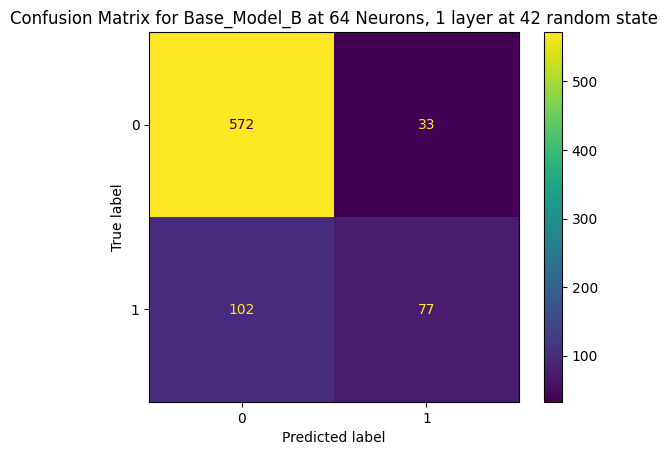

In [33]:
cm = confusion_matrix(y_val, np.round(y_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
#title('Confusion Matrix for Base_Model_A at 64 Neurons, 1 layer at 42 random state')
plt.title('Confusion Matrix for Base_Model_B at 64 Neurons, 1 layer at 42 random state')

_Comment on the graph:_

- The smooth, monotonic improvement in both loss and accuracy strongly suggests that the learning rate was well-chosen. However, the graph suggests `Underfitting` as the point of diverence wasnt reached. _The slope is very steep -0whuch is mostly an indication of a low `learning rate`_
Other possible reasosn for the Underfit could be:
    - the `layers` aren't deep enough (more of this will be xplored subsequenlty)
    - The `neuron` used wasn't sufficient enough (This could be experienmneted with)
    - The `number of epoch` wasnt high enough to ensure complete training and a point of divergence
    - To increase the `learning rate`- possibly.

- The next model will experiemnet for:
    - an epoch size of 250 from 100
    - A learning rate from 0.01 to 0.1
    - The option of a larger neuron with 64 and 128

### __<span style= "color: #92bbcaff;"> Higher Single-layer Neurons </span>__ 

In [34]:
#because the y_label is imbalanced, stratified will used to ensure equal percenatge distribution of the data in both the train and test data

X_temp, X_test, y_temp, y_test = train_test_split(
    x, y, 
    test_size=0.10, 
    random_state=42,
    stratify=y,
    shuffle=True
    )

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.111, 
    random_state=42,
    stratify=y_temp,
    shuffle=True
    )

x_train_scaled = scaler.fit_transform(X_train)
x_val_scaled = scaler.transform(X_val)
x_test_scaled = scaler.transform(X_test)

print("Scaling automatically converts the data_type to a numpy array; so there'd be no need for that step")
print(f"\nx_train data_type: {type(X_train)}")
print(f"x_train_scaled data_type: {type(x_train_scaled)}")

#the numpy conversion is sorted

Scaling automatically converts the data_type to a numpy array; so there'd be no need for that step

x_train data_type: <class 'pandas.core.frame.DataFrame'>
x_train_scaled data_type: <class 'numpy.ndarray'>


=== Training Individual Models ===

--- Training model with 16 neurons ---


c:\Users\kojus\anaconda3\envs\ML_DM\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Completed training for 16 neurons

--- Training model with 32 neurons ---


c:\Users\kojus\anaconda3\envs\ML_DM\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Completed training for 32 neurons

--- Training model with 64 neurons ---


c:\Users\kojus\anaconda3\envs\ML_DM\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Completed training for 64 neurons

--- Training model with 128 neurons ---


c:\Users\kojus\anaconda3\envs\ML_DM\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Completed training for 128 neurons

=== Confusion Matrices ===
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


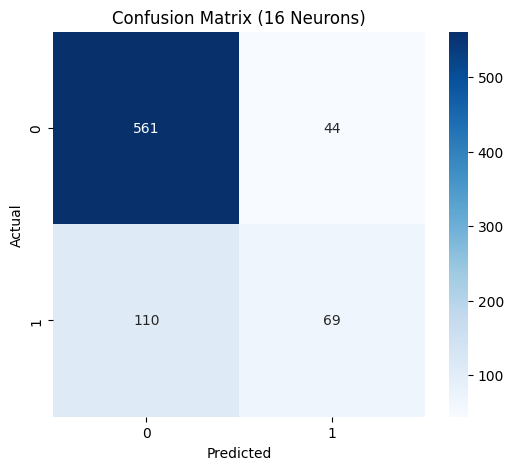

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


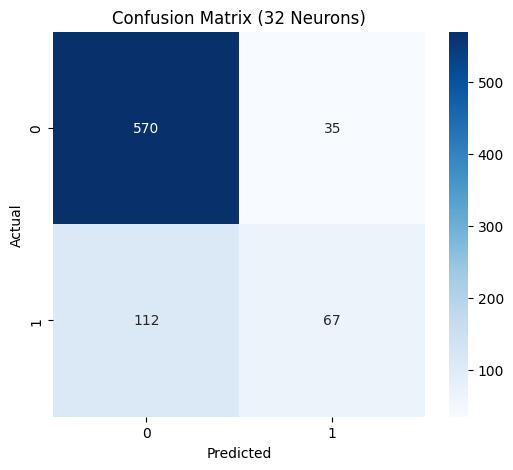

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


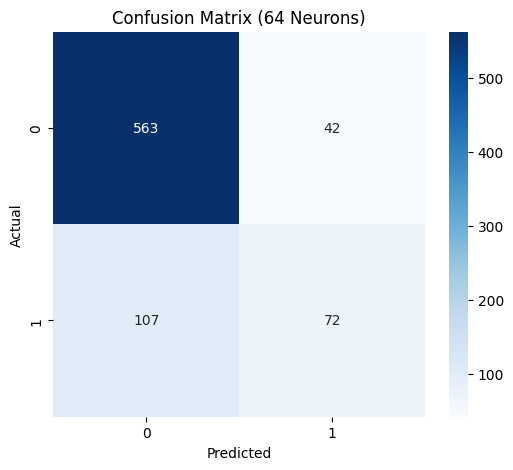

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


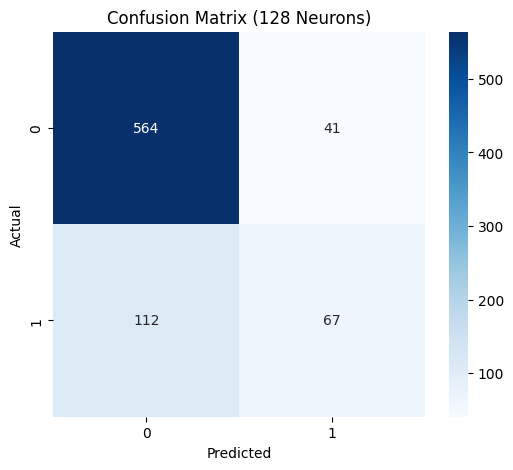


=== Performance Metrics ===

--- 16 Neurons ---
Balanced Accuracy: 0.6564
Recall: 0.3855
F1 Score: 0.4726
Precision: 0.6106
Final Training Loss: 0.4028
Final Validation Loss: 0.4605
Final Validation Accuracy: 0.8036

--- 32 Neurons ---
Balanced Accuracy: 0.6582
Recall: 0.3743
F1 Score: 0.4769
Precision: 0.6569
Final Training Loss: 0.4003
Final Validation Loss: 0.4517
Final Validation Accuracy: 0.8125

--- 64 Neurons ---
Balanced Accuracy: 0.6664
Recall: 0.4022
F1 Score: 0.4915
Precision: 0.6316
Final Training Loss: 0.3975
Final Validation Loss: 0.4531
Final Validation Accuracy: 0.8099

--- 128 Neurons ---
Balanced Accuracy: 0.6533
Recall: 0.3743
F1 Score: 0.4669
Precision: 0.6204
Final Training Loss: 0.3976
Final Validation Loss: 0.4522
Final Validation Accuracy: 0.8048

=== BEST MODEL ===
Best model: 64 neurons
Best Balanced Accuracy: 0.6664


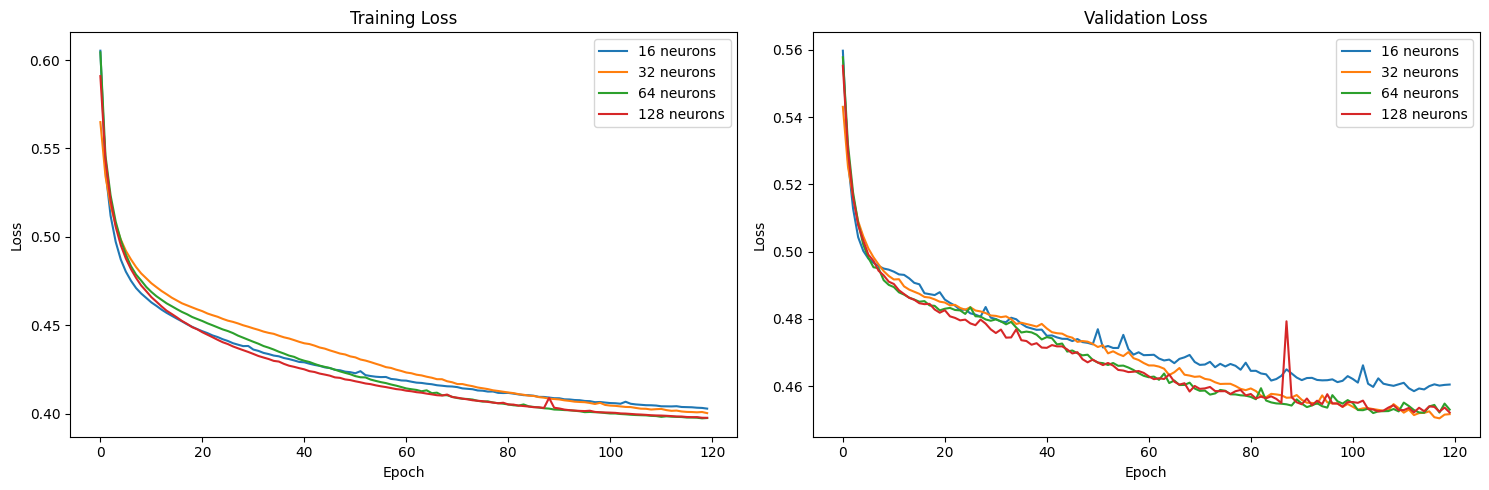

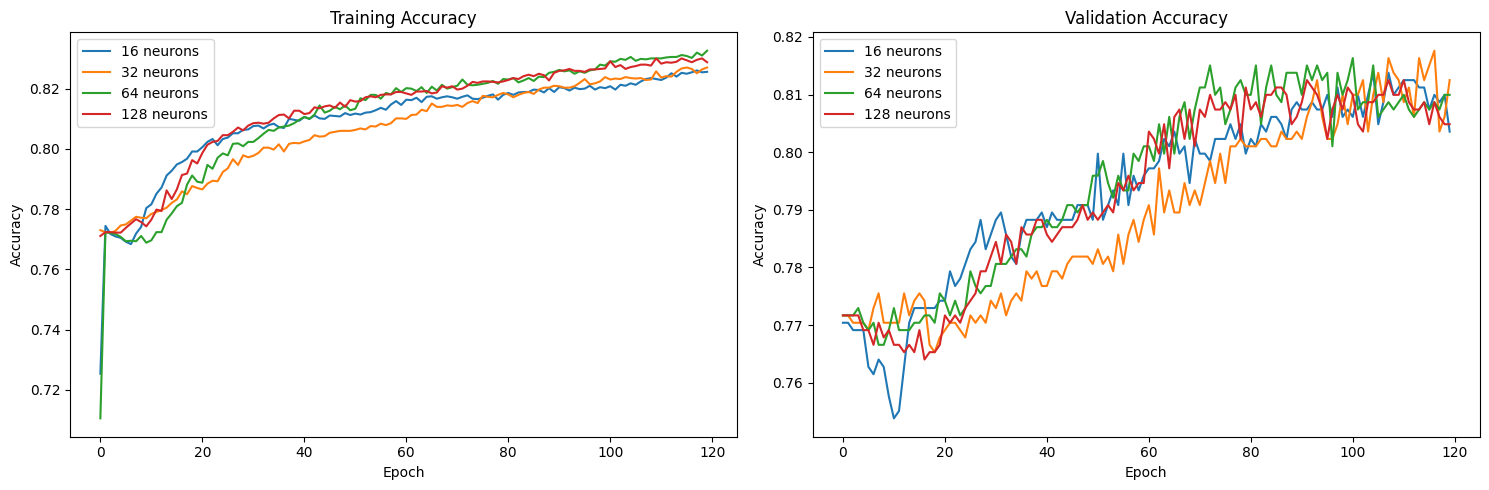

In [35]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def create_model(neurons):
    """Create a single-layer neural network model"""
    model = keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(9,)),  # FIXED: use tf.keras.layers
        tf.keras.layers.Dense(neurons, activation='relu'),  # FIXED
        tf.keras.layers.Dense(1, activation="sigmoid")  # FIXED
    ])
    model.compile(loss='binary_crossentropy', optimizer='SGD', metrics=['accuracy'])
    return model

def show_confusion(model, x_val, y_val, labels=[0,1], title_suffix=''):
    """Display confusion matrix for a model"""
    y_pred = (model.predict(x_val) > 0.5).astype(int)
    cm = confusion_matrix(y_val, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix{title_suffix}')
    plt.show()

# Define neurons to test
neurons = [16, 32, 64, 128]

# Store all results
results = {}
histories = {}

print("=== Training Individual Models ===")

for n in neurons:
    print(f"\n--- Training model with {n} neurons ---")
    
    # Create and train model
    model = create_model(n)
    history = model.fit(x_train_scaled, y_train, 
                       epochs=120, 
                       validation_data=(x_val_scaled, y_val),
                       verbose=0)
    
    # Store history for plotting
    histories[n] = history
    
    # Get predictions
    y_pred = (model.predict(x_val_scaled) > 0.5).astype(int)
    
    # Calculate metrics
    results[n] = {
        'model': model,
        'y_pred': y_pred,
        'recall': recall_score(y_val, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred),
        'final_train_loss': history.history['loss'][-1],
        'final_val_loss': history.history['val_loss'][-1],
        'final_val_accuracy': history.history['val_accuracy'][-1]  # Final validation accuracy
    }
    
    print(f"Completed training for {n} neurons")

# Display confusion matrices
print("\n=== Confusion Matrices ===")
for n in neurons:
    show_confusion(results[n]['model'], x_val_scaled, y_val, 
                   labels=[0,1], title_suffix=f' ({n} Neurons)')

# Print all metrics
print("\n=== Performance Metrics ===")
for n in neurons:
    print(f"\n--- {n} Neurons ---")
    print(f"Balanced Accuracy: {results[n]['balanced_accuracy']:.4f}")
    print(f"Recall: {results[n]['recall']:.4f}")
    print(f"F1 Score: {results[n]['f1']:.4f}")
    print(f"Precision: {results[n]['precision']:.4f}")
    print(f"Final Training Loss: {results[n]['final_train_loss']:.4f}")
    print(f"Final Validation Loss: {results[n]['final_val_loss']:.4f}")
    print(f"Final Validation Accuracy: {results[n]['final_val_accuracy']:.4f}")

# Find best model based on balanced accuracy
best_neurons = max(results.keys(), key=lambda x: results[x]['balanced_accuracy'])
print(f"\n=== BEST MODEL ===")
print(f"Best model: {best_neurons} neurons")
print(f"Best Balanced Accuracy: {results[best_neurons]['balanced_accuracy']:.4f}")

# Plot training history comparison
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
for n in neurons:
    plt.plot(histories[n].history['loss'], label=f'{n} neurons')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
for n in neurons:
    plt.plot(histories[n].history['val_loss'], label=f'{n} neurons')
plt.title('Validation Loss')
plt.xlabel('Epoch') 
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Plot validation accuracy comparison
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
for n in neurons:
    plt.plot(histories[n].history['accuracy'], label=f'{n} neurons')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
for n in neurons:
    plt.plot(histories[n].history['val_accuracy'], label=f'{n} neurons')
plt.title('Validation Accuracy')
plt.xlabel('Epoch') 
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

=== Training Individual Models ===

--- Training model with 16 neurons ---


c:\Users\kojus\anaconda3\envs\ML_DM\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Completed training for 16 neurons

--- Training model with 32 neurons ---


c:\Users\kojus\anaconda3\envs\ML_DM\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Completed training for 32 neurons

--- Training model with 64 neurons ---


c:\Users\kojus\anaconda3\envs\ML_DM\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Completed training for 64 neurons

--- Training model with 128 neurons ---


c:\Users\kojus\anaconda3\envs\ML_DM\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Completed training for 128 neurons

=== Confusion Matrices ===
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


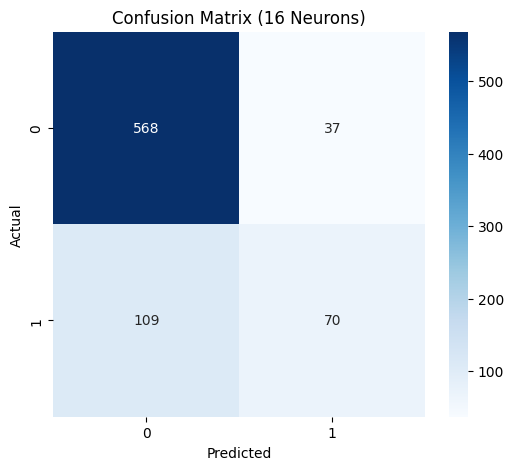

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


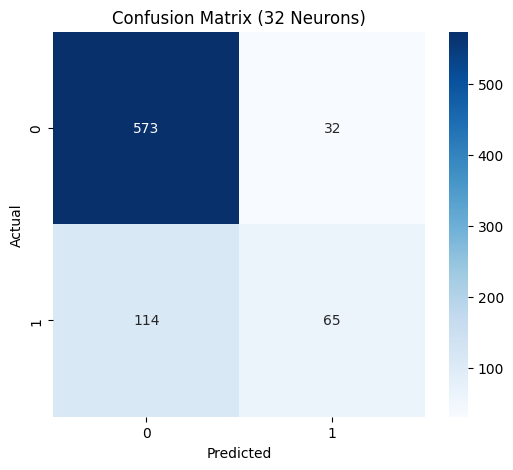

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


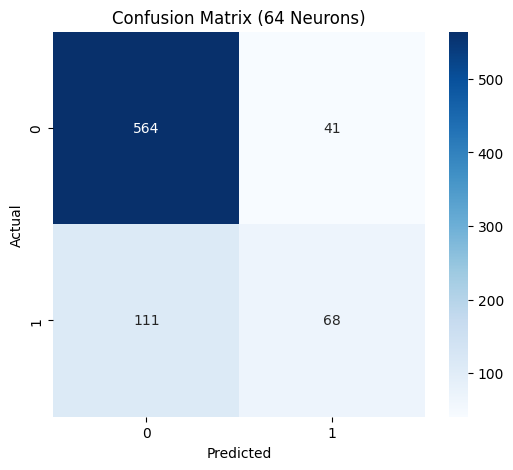

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


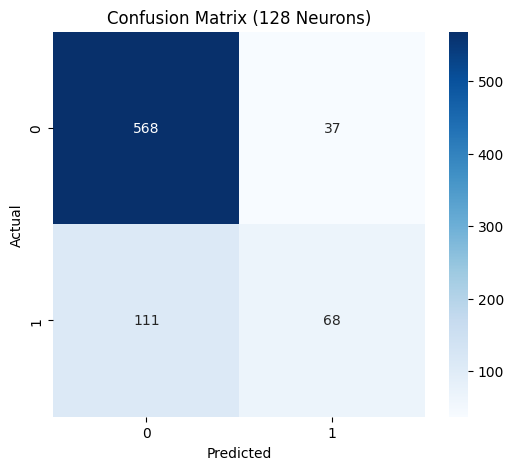


=== Performance Metrics ===

--- 16 Neurons ---
Balanced Accuracy: 0.6650
Recall: 0.3911
F1 Score: 0.4895
Precision: 0.6542
Final Training Loss: 0.4089
Final Validation Loss: 0.4586

--- 32 Neurons ---
Balanced Accuracy: 0.6551
Recall: 0.3631
F1 Score: 0.4710
Precision: 0.6701
Final Training Loss: 0.4009
Final Validation Loss: 0.4515

--- 64 Neurons ---
Balanced Accuracy: 0.6561
Recall: 0.3799
F1 Score: 0.4722
Precision: 0.6239
Final Training Loss: 0.3985
Final Validation Loss: 0.4515

--- 128 Neurons ---
Balanced Accuracy: 0.6594
Recall: 0.3799
F1 Score: 0.4789
Precision: 0.6476
Final Training Loss: 0.3975
Final Validation Loss: 0.4519

=== BEST MODEL ===
Best model: 16 neurons
Best Balanced Accuracy: 0.6650


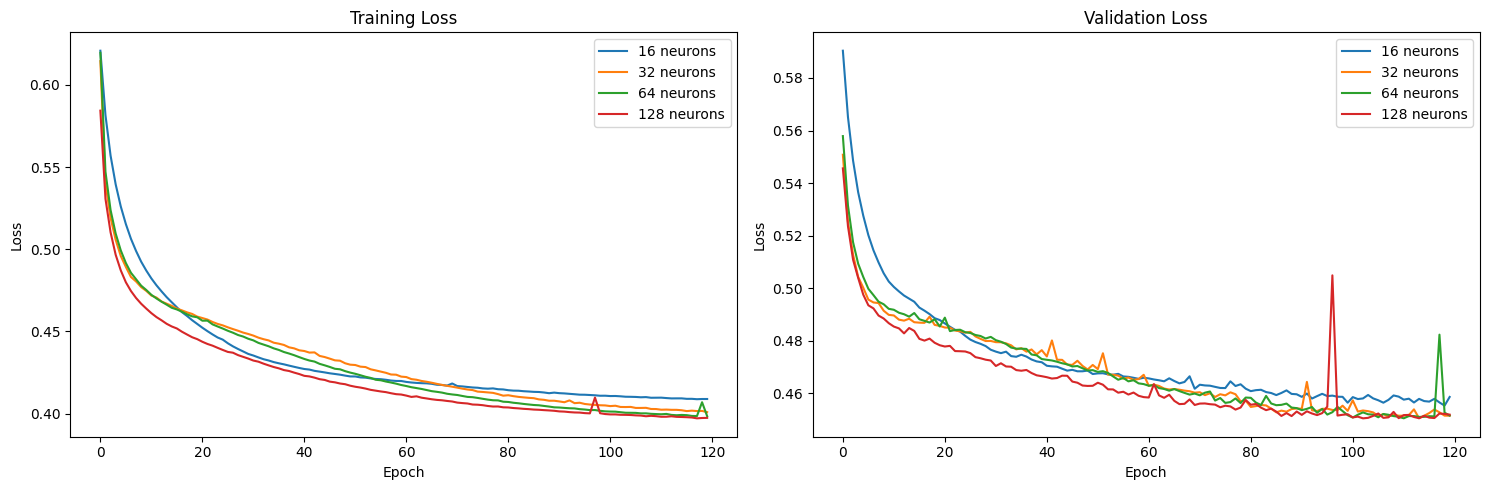

In [36]:
def create_model(neurons):
    """Create a single-layer neural network model"""
    model = keras.Sequential([
        layers.InputLayer(input_shape=(9,)),
        layers.Dense(neurons, activation='relu'),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(loss='binary_crossentropy', optimizer='SGD', metrics=['accuracy'])
    return model

def show_confusion(model, x_val, y_val, labels=[0,1], title_suffix=''):
    """Display confusion matrix for a model"""
    y_pred = (model.predict(x_val) > 0.5).astype(int)
    cm = confusion_matrix(y_val, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix{title_suffix}')
    plt.show()

# Define neurons to test
neurons = [16, 32, 64, 128]

# Store all results
results = {}
histories = {}

print("=== Training Individual Models ===")

for n in neurons:
    print(f"\n--- Training model with {n} neurons ---")
    
    # Create and train model
    model = create_model(n)
    history = model.fit(x_train_scaled, y_train, 
                       epochs=120, 
                       validation_data=(x_val_scaled, y_val),
                       verbose=0)
    
    # Store history for plotting
    histories[n] = history
    
    # Get predictions
    y_pred = (model.predict(x_val_scaled) > 0.5).astype(int)
    
    # Calculate metrics
    results[n] = {
        'model': model,
        'y_pred': y_pred,
        'recall': recall_score(y_val, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred),
        'final_train_loss': history.history['loss'][-1],
        'final_val_loss': history.history['val_loss'][-1]
    }
    
    print(f"Completed training for {n} neurons")

# Display confusion matrices
print("\n=== Confusion Matrices ===")
for n in neurons:
    show_confusion(results[n]['model'], x_val_scaled, y_val, 
                   labels=[0,1], title_suffix=f' ({n} Neurons)')

# Print all metrics
print("\n=== Performance Metrics ===")
for n in neurons:
    print(f"\n--- {n} Neurons ---")
    print(f"Balanced Accuracy: {results[n]['balanced_accuracy']:.4f}")
    print(f"Recall: {results[n]['recall']:.4f}")
    print(f"F1 Score: {results[n]['f1']:.4f}")
    print(f"Precision: {results[n]['precision']:.4f}")
    print(f"Final Training Loss: {results[n]['final_train_loss']:.4f}")
    print(f"Final Validation Loss: {results[n]['final_val_loss']:.4f}")

# Find best model based on balanced accuracy
best_neurons = max(results.keys(), key=lambda x: results[x]['balanced_accuracy'])
print(f"\n=== BEST MODEL ===")
print(f"Best model: {best_neurons} neurons")
print(f"Best Balanced Accuracy: {results[best_neurons]['balanced_accuracy']:.4f}")

# Plot training history comparison
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
for n in neurons:
    plt.plot(histories[n].history['loss'], label=f'{n} neurons')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
for n in neurons:
    plt.plot(histories[n].history['val_loss'], label=f'{n} neurons')
plt.title('Validation Loss')
plt.xlabel('Epoch') 
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

----

### __<span style= "color: #92bbcaff;"> PYRAMID ARCHITECTURE </span>__ 

In [ ]:
# Test all pyramid combinations
pyramids = {
    'pyr_64_32': [64, 32],
    'pyr_64_16': [64, 16], 
    'pyr_32_16': [32, 16],
    'pyr_64_32_16': [64, 32, 16],
    
}

print("PYRAMID ARCHITECTURE PERFORMANCE:")
print("=" * 70)

# Store all results
all_histories = []
all_metrics = []

for name, neurons in pyramids.items():
    print(f"\nTesting {name}: {neurons}")
    
    # Build model - FIXED: Use Input with shape parameter
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(9,)))  # FIXED: Use Input instead of InputLayer
    model.add(tf.keras.layers.Dense(neurons[0], activation='relu'))
    for units in neurons[1:]:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Train model
    history = model.fit(x_train_scaled, y_train, epochs=100, verbose=0, 
                       validation_data=(x_val_scaled, y_val))
    
    # Get final training and validation metrics from history
    final_train_loss = history.history['loss'][-1]
    final_train_acc = history.history['accuracy'][-1]
    final_val_loss = history.history['val_loss'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    
    # Also get metrics from evaluate (for comparison)
    val_loss, val_acc = model.evaluate(x_val_scaled, y_val, verbose=0)
    
    # Calculate ALL metrics - FIXED: Use flattened predictions
    y_pred_prob = model.predict(x_val_scaled, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # CRITICAL: Add .flatten()
    
    # Calculate ALL metrics correctly
    balanced_acc = balanced_accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        # Handle edge cases
        tp = np.sum((y_pred == 1) & (y_val == 1))
        fp = np.sum((y_pred == 1) & (y_val == 0))
        tn = np.sum((y_pred == 0) & (y_val == 0))
        fn = np.sum((y_pred == 0) & (y_val == 1))
    
    # Store COMPLETE results - FIXED: Use consistent key names
    all_histories.append(history.history)
    all_metrics.append({
        'name': name,
        'neurons': neurons,
        'hidden_layers': len(neurons),
        'balanced_accuracy': balanced_acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'final_train_loss': final_train_loss,
        'final_train_acc': final_train_acc,
        'final_val_loss': final_val_loss,
        'final_val_acc': final_val_acc,
        'evaluate_val_loss': val_loss,
        'evaluate_val_acc': val_acc,
        'confusion_matrix': cm,
        'tp': tp,  # FIXED: Use lowercase keys consistently
        'fp': fp,  # FIXED: Use lowercase keys consistently
        'tn': tn,  # FIXED: Use lowercase keys consistently
        'fn': fn   # FIXED: Use lowercase keys consistently
    })
    
    # COMPREHENSIVE PRINT OUTPUT
    print(f"Hidden Layers: {len(neurons)}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f}")
    print(f"Final Training Loss: {final_train_loss:.4f} | Final Validation Loss: {final_val_loss:.4f}")
    print(f"Final Training Acc: {final_train_acc:.4f} | Final Validation Acc: {final_val_acc:.4f}")
    print(f"Confusion Matrix:")
    print(f"                Predicted 0   Predicted 1")
    print(f"Actual 0        TN: {tn:<6}      FP: {fp:<6}")
    print(f"Actual 1        FN: {fn:<6}      TP: {tp:<6}")
    print("-" * 60)

# COMPREHENSIVE FINAL COMPARISON
print("\n" + "=" * 120)
print("FINAL COMPREHENSIVE COMPARISON:")
print("=" * 120)
print(f"{'Model':<15} {'Hidden':<6} {'Bal Acc':<8} {'Precision':<9} {'Recall':<8} {'F1':<8} {'Train Loss':<10} {'Val Loss':<10}")
print("-" * 120)
for metrics in all_metrics:
    print(f"{metrics['name']:<15} {metrics['hidden_layers']:<6} {metrics['balanced_accuracy']:.4f}   "
          f"{metrics['precision']:.4f}     {metrics['recall']:.4f}   {metrics['f1_score']:.4f}   "
          f"{metrics['final_train_loss']:.4f}     {metrics['final_val_loss']:.4f}")

# Rank by different metrics
print("\n" + "=" * 80)
print("RANKED BY BALANCED ACCURACY:")
print("=" * 80)
all_metrics.sort(key=lambda x: x['balanced_accuracy'], reverse=True)
for i, metrics in enumerate(all_metrics):
    print(f"{i+1}. {metrics['name']:15} | BalAcc: {metrics['balanced_accuracy']:.4f} | F1: {metrics['f1_score']:.4f} | Recall: {metrics['recall']:.4f}")

print("\n" + "=" * 80)
print("RANKED BY F1-SCORE:")
print("=" * 80)
all_metrics.sort(key=lambda x: x['f1_score'], reverse=True)
for i, metrics in enumerate(all_metrics):
    print(f"{i+1}. {metrics['name']:15} | F1: {metrics['f1_score']:.4f} | BalAcc: {metrics['balanced_accuracy']:.4f} | Recall: {metrics['recall']:.4f}")

print("\n" + "=" * 80)
print("RANKED BY RECALL:")
print("=" * 80)
all_metrics.sort(key=lambda x: x['recall'], reverse=True)
for i, metrics in enumerate(all_metrics):
    print(f"{i+1}. {metrics['name']:15} | Recall: {metrics['recall']:.4f} | F1: {metrics['f1_score']:.4f} | BalAcc: {metrics['balanced_accuracy']:.4f}")

# Find best models
best_balanced = max(all_metrics, key=lambda x: x['balanced_accuracy'])
best_f1 = max(all_metrics, key=lambda x: x['f1_score'])
best_recall = max(all_metrics, key=lambda x: x['recall'])

print("\n" + "=" * 70)
print("BEST MODELS SUMMARY:")
print("=" * 70)
print(f"🏆 Best Balanced Accuracy: {best_balanced['name']} - {best_balanced['balanced_accuracy']:.4f}")
print(f"🏆 Best F1-Score: {best_f1['name']} - {best_f1['f1_score']:.4f}")
print(f"🏆 Best Recall: {best_recall['name']} - {best_recall['recall']:.4f}")
print("=" * 70)

# DETAILED CONFUSION MATRIX SUMMARY - FIXED: Use lowercase keys
print("\n" + "=" * 80)
print("DETAILED CONFUSION MATRIX ANALYSIS:")
print("=" * 80)
for metrics in all_metrics:
    print(f"\n{metrics['name']} (Neurons: {metrics['neurons']}, Hidden Layers: {metrics['hidden_layers']}):")
    print(f"  Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"  Training Loss: {metrics['final_train_loss']:.4f} | Validation Loss: {metrics['final_val_loss']:.4f}")
    print(f"  True Negatives (TN): {metrics['tn']} | False Positives (FP): {metrics['fp']}")  # FIXED: lowercase
    print(f"  False Negatives (FN): {metrics['fn']} | True Positives (TP): {metrics['tp']}")  # FIXED: lowercase
    print(f"  Default Detection Rate (Recall): {metrics['recall']:.1%}")
    if metrics['fp'] + metrics['tn'] > 0:
        print(f"  False Positive Rate: {metrics['fp']/(metrics['fp'] + metrics['tn']):.1%}")
    else:
        print(f"  False Positive Rate: 0.0%")

# PLOT 1: Training Progress
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
colors = ['blue', 'red', 'green', 'orange']

for i, (name, history_dict) in enumerate(zip(pyramids.keys(), all_histories)):
    # Training Accuracy
    ax1.plot(history_dict['accuracy'], label=name, color=colors[i], linewidth=2)
    # Validation Accuracy  
    ax2.plot(history_dict['val_accuracy'], label=name, color=colors[i], linewidth=2)
    # Training Loss
    ax3.plot(history_dict['loss'], label=name, color=colors[i], linewidth=2)
    # Validation Loss
    ax4.plot(history_dict['val_loss'], label=name, color=colors[i], linewidth=2)

ax1.set_ylabel('Training Accuracy')
ax2.set_ylabel('Validation Accuracy')
ax3.set_ylabel('Training Loss')
ax4.set_ylabel('Validation Loss')
ax3.set_xlabel('Epochs')
ax4.set_xlabel('Epochs')
ax1.set_title('Training Accuracy')
ax2.set_title('Validation Accuracy')
ax3.set_title('Training Loss')
ax4.set_title('Validation Loss')
ax2.legend()
plt.suptitle('Pyramid Architectures - Training Progress', fontsize=16)
plt.tight_layout()
plt.show()

# PLOT 2: Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, metrics in enumerate(all_metrics):
    cm = metrics['confusion_matrix']
    im = axes[i].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    axes[i].set_title(f'{metrics["name"]}\nBalAcc: {metrics["balanced_accuracy"]:.3f}\nTP:{metrics["tp"]}, FP:{metrics["fp"]}, FN:{metrics["fn"]}, TN:{metrics["tn"]}')
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(['Pred 0', 'Pred 1'])
    axes[i].set_yticklabels(['True 0', 'True 1'])
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i_arr in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[i].text(j, i_arr, format(cm[i_arr, j], 'd'),
                       ha="center", va="center",
                       color="white" if cm[i_arr, j] > thresh else "black")

plt.suptitle('Pyramid Architectures - Confusion Matrices', fontsize=16)
plt.tight_layout()
plt.show()

# PLOT 3: Metric Comparison
fig, ax = plt.subplots(figsize=(12, 6))
model_names = [m['name'] for m in all_metrics]
x = np.arange(len(model_names))
width = 0.2

balanced_accs = [m['balanced_accuracy'] for m in all_metrics]
precisions = [m['precision'] for m in all_metrics]
recalls = [m['recall'] for m in all_metrics]
f1_scores = [m['f1_score'] for m in all_metrics]

bars1 = ax.bar(x - 1.5*width, balanced_accs, width, label='Balanced Accuracy', color='skyblue')
bars2 = ax.bar(x - 0.5*width, precisions, width, label='Precision', color='lightgreen')
bars3 = ax.bar(x + 0.5*width, recalls, width, label='Recall', color='lightcoral')
bars4 = ax.bar(x + 1.5*width, f1_scores, width, label='F1-Score', color='gold')

ax.set_ylabel('Scores')
ax.set_title('Pyramid Architectures: Comprehensive Metric Comparison')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim(0, 1)

# Add value labels
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# EXPORT FOR ACADEMIC TABLE
print("\n" + "=" * 100)
print("COPY FOR ACADEMIC TABLE:")
print("=" * 100)
print("Architecture | Hidden Layers | Neurons | Balanced Accuracy | Precision | Recall | F1-Score | Final Train Loss | Final Val Loss | TP | FP | FN | TN")
for metrics in all_metrics:
    print(f"{metrics['name']} | {metrics['hidden_layers']} | {metrics['neurons']} | {metrics['balanced_accuracy']:.4f} | "
          f"{metrics['precision']:.4f} | {metrics['recall']:.4f} | {metrics['f1_score']:.4f} | "
          f"{metrics['final_train_loss']:.4f} | {metrics['final_val_loss']:.4f} | "
          f"{metrics['tp']} | {metrics['fp']} | {metrics['fn']} | {metrics['tn']}")

PYRAMID ARCHITECTURE PERFORMANCE:

Testing pyr_64_32: [64, 32]
Hidden Layers: 2
Balanced Accuracy: 0.6837
Precision: 0.5667 | Recall: 0.4749 | F1-Score: 0.5167
Final Training Loss: 0.3491 | Final Validation Loss: 0.4895
Final Training Acc: 0.8460 | Final Validation Acc: 0.7972
Confusion Matrix:
                Predicted 0   Predicted 1
Actual 0        TN: 540         FP: 65    
Actual 1        FN: 94          TP: 85    
------------------------------------------------------------

Testing pyr_64_16: [64, 16]
Hidden Layers: 2
Balanced Accuracy: 0.6812
Precision: 0.5556 | Recall: 0.4749 | F1-Score: 0.5120
Final Training Loss: 0.3599 | Final Validation Loss: 0.4788
Final Training Acc: 0.8457 | Final Validation Acc: 0.7934
Confusion Matrix:
                Predicted 0   Predicted 1
Actual 0        TN: 537         FP: 68    
Actual 1        FN: 94          TP: 85    
------------------------------------------------------------

Testing pyr_32_16: [32, 16]
Hidden Layers: 2
Balanced Accuracy:

In [ ]:
# Test all pyramid combinations
pyramids = {
    'pyr_64_32': [64, 32],
    'pyr_64_16': [64, 16], 
    'pyr_32_16': [32, 16],
    'pyr_64_32_16': [64, 32, 16]
}

print("PYRAMID ARCHITECTURE PERFORMANCE:")
print("=" * 70)

# Store all results
all_histories = []
all_metrics = []

for name, neurons in pyramids.items():
    print(f"\nTesting {name}: {neurons}")
    
    # Build model - FIXED: Use InputLayer to avoid warning
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=(9,)))  # FIXED
    model.add(tf.keras.layers.Dense(neurons[0], activation='relu'))
    for units in neurons[1:]:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Train model
    history = model.fit(x_train_scaled, y_train, epochs=100, verbose=0, 
                       validation_data=(x_val_scaled, y_val))
    
    # Get final training and validation metrics from history
    final_train_loss = history.history['loss'][-1]        # ADDED
    final_train_acc = history.history['accuracy'][-1]     # ADDED
    final_val_loss = history.history['val_loss'][-1]      # ADDED
    final_val_acc = history.history['val_accuracy'][-1]   # ADDED
    
    # Also get metrics from evaluate (for comparison)
    val_loss, val_acc = model.evaluate(x_val_scaled, y_val, verbose=0)
    
    # Calculate metrics
    y_pred_prob = model.predict(x_val_scaled, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Store results
    all_histories.append(history.history)
    all_metrics.append({
        'name': name,
        'neurons': neurons,
        'final_train_loss': final_train_loss,    # ADDED
        'final_train_acc': final_train_acc,      # ADDED
        'final_val_loss': final_val_loss,        # ADDED
        'final_val_acc': final_val_acc,          # ADDED
        'evaluate_val_loss': val_loss,           # For comparison
        'evaluate_val_acc': val_acc,             # For comparison
        'recall': recall,
        'precision': precision,
        'f1_score': f1,
        'confusion_matrix': cm,
        'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn
    })
    
    # UPDATED PRINT WITH BOTH TRAINING AND VALIDATION LOSS
    print(f"Final Training Loss: {final_train_loss:.4f} | Final Validation Loss: {final_val_loss:.4f}")
    print(f"Final Training Acc: {final_train_acc:.4f} | Final Validation Acc: {final_val_acc:.4f}")
    print(f"Metrics -> Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    print(f"Confusion Matrix:")
    print(f"                Predicted 0   Predicted 1")
    print(f"Actual 0        TN: {tn:<6}      FP: {fp:<6}")
    print(f"Actual 1        FN: {fn:<6}      TP: {tp:<6}")
    print("-" * 50)

# Print final comparison WITH BOTH LOSSES
print("\n" + "=" * 100)
print("FINAL COMPARISON:")
print("=" * 100)
print(f"{'Model':<15} {'Train Loss':<12} {'Val Loss':<12} {'Train Acc':<10} {'Val Acc':<10} {'Precision':<9} {'Recall':<8} {'F1':<8}")
print("-" * 100)
for metrics in all_metrics:
    print(f"{metrics['name']:<15} {metrics['final_train_loss']:.4f}      {metrics['final_val_loss']:.4f}      "
          f"{metrics['final_train_acc']:.4f}     {metrics['final_val_acc']:.4f}     "
          f"{metrics['precision']:.4f}     {metrics['recall']:.4f}   {metrics['f1_score']:.4f}")

# Print detailed confusion matrices summary
print("\n" + "=" * 80)
print("DETAILED CONFUSION MATRICES:")
print("=" * 80)
for metrics in all_metrics:
    print(f"\n{metrics['name']} (Neurons: {metrics['neurons']}):")
    print(f"  Training Loss: {metrics['final_train_loss']:.4f} | Validation Loss: {metrics['final_val_loss']:.4f}")
    print(f"  Training Acc: {metrics['final_train_acc']:.4f} | Validation Acc: {metrics['final_val_acc']:.4f}")
    print(f"  True Negatives (TN): {metrics['tn']} | False Positives (FP): {metrics['fp']}")
    print(f"  False Negatives (FN): {metrics['fn']} | True Positives (TP): {metrics['tp']}")
    print(f"  Default Detection Rate: {metrics['recall']:.1%}")

# Plot training progress
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Training Loss
for i, (name, history_dict) in enumerate(zip(pyramids.keys(), all_histories)):
    ax1.plot(history_dict['loss'], label=f"{name}", linewidth=2)
ax1.set_ylabel('Training Loss')
ax1.set_xlabel('Epochs')
ax1.set_title('Training Loss Over Epochs')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Validation Loss
for i, (name, history_dict) in enumerate(zip(pyramids.keys(), all_histories)):
    ax2.plot(history_dict['val_loss'], label=f"{name}", linewidth=2)
ax2.set_ylabel('Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_title('Validation Loss Over Epochs')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Training Accuracy
for i, (name, history_dict) in enumerate(zip(pyramids.keys(), all_histories)):
    ax3.plot(history_dict['accuracy'], label=f"{name}", linewidth=2)
ax3.set_ylabel('Training Accuracy')
ax3.set_xlabel('Epochs')
ax3.set_title('Training Accuracy Over Epochs')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Validation Accuracy
for i, (name, history_dict) in enumerate(zip(pyramids.keys(), all_histories)):
    ax4.plot(history_dict['val_accuracy'], label=f"{name}", linewidth=2)
ax4.set_ylabel('Validation Accuracy')
ax4.set_xlabel('Epochs')
ax4.set_title('Validation Accuracy Over Epochs')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('Pyramid Architectures - Training Progress', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, f1_score, confusion_matrix
import tensorflow as tf
import numpy as np

# Test all pyramid combinations
pyramids = {
    'pyr_64_32': [64, 32],
    'pyr_64_16': [64, 16], 
    'pyr_32_16': [32, 16],
    'pyr_64_32_16': [64, 32, 16]
}

print("PYRAMID ARCHITECTURE PERFORMANCE:")
print("=" * 70)

# Store all results
all_histories = []
all_metrics = []

for name, neurons in pyramids.items():
    print(f"\nTesting {name}: {neurons}")
    
    # Build model
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(neurons[0], activation='relu', input_shape=(9,)))
    for units in neurons[1:]:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Train model
    history = model.fit(x_train_scaled, y_train, epochs=100, verbose=0, 
                       validation_data=(x_val_scaled, y_val))
    
    # Get final metrics
    val_loss, val_acc = model.evaluate(x_val_scaled, y_val, verbose=0)
    
    # ADDED: Get final training loss from history
    final_train_loss = history.history['loss'][-1]
    final_train_acc = history.history['accuracy'][-1]
    final_val_loss = history.history['val_loss'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    
    # Calculate metrics
    y_pred_prob = model.predict(x_val_scaled, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Store results
    all_histories.append(history.history)
    all_metrics.append({
        'name': name,
        'neurons': neurons,
        'val_accuracy': val_acc,
        'val_loss': val_loss,
        'final_train_loss': final_train_loss,  # ADDED
        'final_train_acc': final_train_acc,    # ADDED
        'final_val_loss': final_val_loss,      # ADDED
        'final_val_acc': final_val_acc,        # ADDED
        'recall': recall,
        'precision': precision,
        'f1_score': f1,
        'confusion_matrix': cm,
        'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn
    })
    
    # UPDATED PRINT WITH FINAL LOSSES AND CONFUSION MATRIX
    print(f"Final Training Loss: {final_train_loss:.4f} | Final Validation Loss: {final_val_loss:.4f}")
    print(f"Final Training Acc: {final_train_acc:.4f} | Final Validation Acc: {final_val_acc:.4f}")
    print(f"Metrics -> Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    print(f"Confusion Matrix:")
    print(f"                Predicted 0   Predicted 1")
    print(f"Actual 0        TN: {tn:<6}      FP: {fp:<6}")
    print(f"Actual 1        FN: {fn:<6}      TP: {tp:<6}")
    print("-" * 50)

# Print final comparison WITH ALL LOSS INFORMATION
print("\n" + "=" * 100)
print("FINAL COMPARISON:")
print("=" * 100)
print(f"{'Model':<15} {'Train Loss':<10} {'Val Loss':<10} {'Train Acc':<10} {'Val Acc':<10} {'Precision':<10} {'Recall':<8} {'F1':<8}")
print("-" * 100)
for metrics in all_metrics:
    print(f"{metrics['name']:<15} {metrics['final_train_loss']:.4f}    {metrics['final_val_loss']:.4f}    "
          f"{metrics['final_train_acc']:.4f}     {metrics['final_val_acc']:.4f}     "
          f"{metrics['precision']:.4f}      {metrics['recall']:.4f}   {metrics['f1_score']:.4f}")

# Print detailed confusion matrices summary
print("\n" + "=" * 80)
print("DETAILED CONFUSION MATRICES:")
print("=" * 80)
for metrics in all_metrics:
    print(f"\n{metrics['name']} (Neurons: {metrics['neurons']}):")
    print(f"  True Negatives (TN): {metrics['tn']} - Correctly predicted No Default")
    print(f"  False Positives (FP): {metrics['fp']} - Incorrectly predicted as Default")
    print(f"  False Negatives (FN): {metrics['fn']} - Missed actual Defaults")
    print(f"  True Positives (TP): {metrics['tp']} - Correctly predicted Default")
    print(f"  Total Samples: {metrics['tn'] + metrics['fp'] + metrics['fn'] + metrics['tp']}")
    print(f"  Default Detection Rate: {metrics['recall']:.1%}")

# Plot all architectures together
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Training Loss
for i, (name, history_dict) in enumerate(zip(pyramids.keys(), all_histories)):
    ax1.plot(history_dict['loss'], label=name, linewidth=2)
ax1.set_ylabel('Training Loss')
ax1.set_xlabel('Epochs')
ax1.set_title('Training Loss Over Epochs')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Validation Loss
for i, (name, history_dict) in enumerate(zip(pyramids.keys(), all_histories)):
    ax2.plot(history_dict['val_loss'], label=name, linewidth=2)
ax2.set_ylabel('Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_title('Validation Loss Over Epochs')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Training Accuracy
for i, (name, history_dict) in enumerate(zip(pyramids.keys(), all_histories)):
    ax3.plot(history_dict['accuracy'], label=name, linewidth=2)
ax3.set_ylabel('Training Accuracy')
ax3.set_xlabel('Epochs')
ax3.set_title('Training Accuracy Over Epochs')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Validation Accuracy
for i, (name, history_dict) in enumerate(zip(pyramids.keys(), all_histories)):
    ax4.plot(history_dict['val_accuracy'], label=name, linewidth=2)
ax4.set_ylabel('Validation Accuracy')
ax4.set_xlabel('Epochs')
ax4.set_title('Validation Accuracy Over Epochs')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('Pyramid Architectures - Training Progress', fontsize=16)
plt.tight_layout()
plt.show()

# Plot confusion matrices for each architecture
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, metrics in enumerate(all_metrics):
    cm = metrics['confusion_matrix']
    im = axes[i].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    axes[i].set_title(f'{metrics["name"]}\nNeurons: {metrics["neurons"]}\nTP:{metrics["tp"]}, FP:{metrics["fp"]}, FN:{metrics["fn"]}, TN:{metrics["tn"]}')
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(['Pred 0\n(No Default)', 'Pred 1\n(Default)'])
    axes[i].set_yticklabels(['True 0\n(No Default)', 'True 1\n(Default)'])
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i_arr in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[i].text(j, i_arr, format(cm[i_arr, j], 'd'),
                       ha="center", va="center",
                       color="white" if cm[i_arr, j] > thresh else "black")

plt.suptitle('Pyramid Architectures - Confusion Matrices', fontsize=16)
plt.tight_layout()
plt.show()

# Export for academic table
print("\n" + "=" * 90)
print("COPY THIS FOR YOUR ACADEMIC TABLE:")
print("=" * 90)
print("Architecture | Neurons | Train Loss | Val Loss | Train Acc | Val Acc | Precision | Recall | F1-Score | TP | FP | FN | TN")
for metrics in all_metrics:
    print(f"{metrics['name']} | {metrics['neurons']} | {metrics['final_train_loss']:.4f} | {metrics['final_val_loss']:.4f} | "
          f"{metrics['final_train_acc']:.4f} | {metrics['final_val_acc']:.4f} | {metrics['precision']:.4f} | "
          f"{metrics['recall']:.4f} | {metrics['f1_score']:.4f} | {metrics['tp']} | {metrics['fp']} | {metrics['fn']} | {metrics['tn']}")

In [ ]:

# Test all pyramid combinations
pyramids = {
    'pyr_64_32': [64, 32],
    'pyr_64_16': [64, 16], 
    'pyr_32_16': [32, 16],
    'pyr_64_32_16': [64, 32, 16]
}

print("PYRAMID ARCHITECTURE PERFORMANCE:")
print("=" * 50)

# Store all results
all_histories = []
all_metrics = []

for name, neurons in pyramids.items():
    print(f"\nTesting {name}: {neurons}")
    
    # Build model
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(neurons[0], activation='relu', input_shape=(9,)))
    for units in neurons[1:]:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Train model
    history = model.fit(x_train_scaled, y_train, epochs=100, verbose=0, 
                       validation_data=(x_val_scaled, y_val))
    
    # Get final metrics
    val_loss, val_acc = model.evaluate(x_val_scaled, y_val, verbose=0)
    
    # Calculate metrics
    y_pred_prob = model.predict(x_val_scaled, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    
    # ADDED: Calculate confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Store results
    all_histories.append(history.history)
    all_metrics.append({
        'name': name,
        'neurons': neurons,
        'val_accuracy': val_acc,
        'val_loss': val_loss,
        'recall': recall,
        'precision': precision,
        'f1_score': f1,
        'confusion_matrix': cm,  # ADDED
        'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn  # ADDED
    })
    
    # UPDATED PRINT WITH CONFUSION MATRIX
    print(f"Accuracy: {val_acc:.4f} | Loss: {val_loss:.4f} | Recall: {recall:.4f} | Precision: {precision:.4f} | F1: {f1:.4f}")
    print(f"Confusion Matrix:")
    print(f"                Predicted 0   Predicted 1")
    print(f"Actual 0        TN: {tn:<6}      FP: {fp:<6}")
    print(f"Actual 1        FN: {fn:<6}      TP: {tp:<6}")
    print("-" * 40)

# Print final comparison
print("\n" + "=" * 80)
print("FINAL COMPARISON:")
print("=" * 80)
for metrics in all_metrics:
    print(f"{metrics['name']:15} | Acc: {metrics['val_accuracy']:.4f} | "
          f"Loss: {metrics['val_loss']:.4f} | Recall: {metrics['recall']:.4f} | "
          f"Precision: {metrics['precision']:.4f} | F1: {metrics['f1_score']:.4f}")

# Print confusion matrices summary
print("\n" + "=" * 60)
print("CONFUSION MATRICES SUMMARY:")
print("=" * 60)
for metrics in all_metrics:
    print(f"\n{metrics['name']}:")
    print(f"  True Negatives: {metrics['tn']} | False Positives: {metrics['fp']}")
    print(f"  False Negatives: {metrics['fn']} | True Positives: {metrics['tp']}")
    print(f"  Total Samples: {metrics['tn'] + metrics['fp'] + metrics['fn'] + metrics['tp']}")

# Plot all architectures together
fig, (ax1, ax2) = plt.subplots(2, figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange']

for i, (name, history_dict) in enumerate(zip(pyramids.keys(), all_histories)):
    ax1.plot(history_dict['val_accuracy'], label=name, color=colors[i])
    ax2.plot(history_dict['val_loss'], label=name, color=colors[i])

ax1.set_ylabel('Validation Accuracy')
ax2.set_ylabel('Validation Loss')
ax2.set_xlabel('Epochs')
ax1.legend()
ax2.legend()
ax1.set_title('Pyramid Architectures Comparison')
plt.tight_layout()
plt.show()

# ADDED: Plot confusion matrices for each architecture
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, metrics in enumerate(all_metrics):
    cm = metrics['confusion_matrix']
    im = axes[i].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    axes[i].set_title(f'{metrics["name"]}\nTP:{metrics["tp"]}, FP:{metrics["fp"]}\nFN:{metrics["fn"]}, TN:{metrics["tn"]}')
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(['Pred 0', 'Pred 1'])
    axes[i].set_yticklabels(['True 0', 'True 1'])
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i_arr in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[i].text(j, i_arr, format(cm[i_arr, j], 'd'),
                       ha="center", va="center",
                       color="white" if cm[i_arr, j] > thresh else "black")

plt.suptitle('Pyramid Architectures - Confusion Matrices', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Test all pyramid combinations
pyramids = {
    'pyr_64_32': [64, 32],
    'pyr_64_16': [64, 16], 
    'pyr_32_16': [32, 16],
    'pyr_64_32_16': [64, 32, 16]
}

print("PYRAMID ARCHITECTURE PERFORMANCE:")
print("=" * 70)

# Store all results
all_histories = []
all_metrics = []

for name, neurons in pyramids.items():
    print(f"\nTesting {name}: {neurons}")
    
    # Build and train model
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(neurons[0], activation='relu', input_shape=(9,)))
    for units in neurons[1:]:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    history = model.fit(x_train_scaled, y_train, epochs=100, verbose=0, 
                       validation_data=(x_val_scaled, y_val))
    
    # Get predictions
    y_pred_prob = model.predict(x_val_scaled, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    # Calculate COMPLETE metrics including balanced accuracy
    val_loss, val_acc = model.evaluate(x_val_scaled, y_val, verbose=0)
    balanced_acc = balanced_accuracy_score(y_val, y_pred)  # NEW
    precision = precision_score(y_val, y_pred, zero_division=0)  # NEW
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)  # NEW
    
    # Store results
    all_histories.append(history.history)
    all_metrics.append({
        'name': name, 'neurons': neurons,
        'val_accuracy': val_acc, 'val_loss': val_loss, 
        'balanced_accuracy': balanced_acc,  # NEW
        'precision': precision,  # NEW
        'recall': recall, 
        'f1_score': f1  # NEW
    })
    
    print(f"Accuracy: {val_acc:.4f} | Balanced Acc: {balanced_acc:.4f}")  # UPDATED
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")  # UPDATED

# Print final comparison with ALL metrics
print("\n" + "=" * 80)
print("FINAL COMPARISON WITH COMPLETE METRICS:")
print("=" * 80)
print(f"{'Model':<15} {'Balanced Acc':<12} {'Precision':<10} {'Recall':<8} {'F1-Score':<8}")
print("-" * 80)
for metrics in all_metrics:
    print(f"{metrics['name']:<15} {metrics['balanced_accuracy']:.4f}      "
          f"{metrics['precision']:.4f}     "
          f"{metrics['recall']:.4f}   "
          f"{metrics['f1_score']:.4f}")

# Find best model by F1-score (most balanced metric)
best_model = max(all_metrics, key=lambda x: x['f1_score'])
print(f"\n🏆 BEST MODEL: {best_model['name']}")
print(f"   F1-Score: {best_model['f1_score']:.4f}, Balanced Accuracy: {best_model['balanced_accuracy']:.4f}")

# Create 2x2 subplot with training AND validation
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))
colors = ['blue', 'red', 'green', 'orange']

for i, (name, history_dict) in enumerate(zip(pyramids.keys(), all_histories)):
    # Top left: Training Accuracy
    ax1.plot(history_dict['accuracy'], label=name, color=colors[i])
    # Top right: Validation Accuracy  
    ax2.plot(history_dict['val_accuracy'], label=name, color=colors[i])
    # Bottom left: Training Loss
    ax3.plot(history_dict['loss'], label=name, color=colors[i])
    # Bottom right: Validation Loss
    ax4.plot(history_dict['val_loss'], label=name, color=colors[i])

# Labels and legends
ax1.set_ylabel('Training Accuracy')
ax2.set_ylabel('Validation Accuracy')
ax3.set_ylabel('Training Loss')
ax4.set_ylabel('Validation Loss')
ax1.set_title('Pyramid Architectures: Training Curves')

for ax in [ax3, ax4]:
    ax.set_xlabel('Epochs')

ax2.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf

# Test all pyramid combinations
pyramids = {
    'pyr_64_32': [64, 32],
    'pyr_64_16': [64, 16], 
    'pyr_32_16': [32, 16],
    'pyr_64_32_16': [64, 32, 16]
}

print("PYRAMID ARCHITECTURE PERFORMANCE:")
print("=" * 70)

# Store all results
all_histories = []
all_metrics = []

for name, neurons in pyramids.items():
    print(f"\nTesting {name}: {neurons}")
    
    # Build model - FIXED: Use InputLayer to avoid warning
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=(9,)))  # FIXED
    model.add(tf.keras.layers.Dense(neurons[0], activation='relu'))
    for units in neurons[1:]:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Train model
    history = model.fit(x_train_scaled, y_train, epochs=100, verbose=0, 
                       validation_data=(x_val_scaled, y_val))
    
    # Get final training and validation metrics from history
    final_train_loss = history.history['loss'][-1]        # ADDED
    final_train_acc = history.history['accuracy'][-1]     # ADDED
    final_val_loss = history.history['val_loss'][-1]      # ADDED
    final_val_acc = history.history['val_accuracy'][-1]   # ADDED
    
    # Also get metrics from evaluate (for comparison)
    val_loss, val_acc = model.evaluate(x_val_scaled, y_val, verbose=0)
    
    # Calculate metrics
    y_pred_prob = model.predict(x_val_scaled, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # Added flatten() for balanced_accuracy_score
    
    # ADDED: Calculate balanced accuracy
    balanced_acc = balanced_accuracy_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Store results
    all_histories.append(history.history)
    all_metrics.append({
        'name': name,
        'neurons': neurons,
        'balanced_accuracy': balanced_acc,        # ADDED
        'final_train_loss': final_train_loss,
        'final_train_acc': final_train_acc,
        'final_val_loss': final_val_loss,
        'final_val_acc': final_val_acc,
        'evaluate_val_loss': val_loss,
        'evaluate_val_acc': val_acc,
        'recall': recall,
        'precision': precision,
        'f1_score': f1,
        'confusion_matrix': cm,
        'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn
    })
    
    # UPDATED PRINT WITH BALANCED ACCURACY
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"Final Training Loss: {final_train_loss:.4f} | Final Validation Loss: {final_val_loss:.4f}")
    print(f"Final Training Acc: {final_train_acc:.4f} | Final Validation Acc: {final_val_acc:.4f}")
    print(f"Metrics -> Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    print(f"Confusion Matrix:")
    print(f"                Predicted 0   Predicted 1")
    print(f"Actual 0        TN: {tn:<6}      FP: {fp:<6}")
    print(f"Actual 1        FN: {fn:<6}      TP: {tp:<6}")
    print("-" * 50)

# Print final comparison WITH BALANCED ACCURACY
print("\n" + "=" * 120)
print("FINAL COMPARISON:")
print("=" * 120)
print(f"{'Model':<15} {'Bal Acc':<8} {'Train Loss':<12} {'Val Loss':<12} {'Train Acc':<10} {'Val Acc':<10} {'Precision':<9} {'Recall':<8} {'F1':<8}")
print("-" * 120)
for metrics in all_metrics:
    print(f"{metrics['name']:<15} {metrics['balanced_accuracy']:.4f}   {metrics['final_train_loss']:.4f}      {metrics['final_val_loss']:.4f}      "
          f"{metrics['final_train_acc']:.4f}     {metrics['final_val_acc']:.4f}     "
          f"{metrics['precision']:.4f}     {metrics['recall']:.4f}   {metrics['f1_score']:.4f}")

# Print detailed confusion matrices summary WITH BALANCED ACCURACY
print("\n" + "=" * 80)
print("DETAILED CONFUSION MATRICES:")
print("=" * 80)
for metrics in all_metrics:
    print(f"\n{metrics['name']} (Neurons: {metrics['neurons']}):")
    print(f"  Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"  Training Loss: {metrics['final_train_loss']:.4f} | Validation Loss: {metrics['final_val_loss']:.4f}")
    print(f"  Training Acc: {metrics['final_train_acc']:.4f} | Validation Acc: {metrics['final_val_acc']:.4f}")
    print(f"  True Negatives (TN): {metrics['tn']} | False Positives (FP): {metrics['fp']}")
    print(f"  False Negatives (FN): {metrics['fn']} | True Positives (TP): {metrics['tp']}")
    print(f"  Default Detection Rate: {metrics['recall']:.1%}")

# Find best model by Balanced Accuracy
best_model = max(all_metrics, key=lambda x: x['balanced_accuracy'])
print("\n" + "=" * 60)
print(f"BEST PYRAMID MODEL BY BALANCED ACCURACY: {best_model['name']}")
print(f"Neurons: {best_model['neurons']}")
print(f"Balanced Accuracy: {best_model['balanced_accuracy']:.4f}")
print(f"F1-Score: {best_model['f1_score']:.4f}")
print(f"Recall: {best_model['recall']:.4f}")
print("=" * 60)

# Rank models by Balanced Accuracy
print("\nRANKED BY BALANCED ACCURACY:")
print("-" * 50)
all_metrics.sort(key=lambda x: x['balanced_accuracy'], reverse=True)
for i, metrics in enumerate(all_metrics):
    print(f"{i+1}. {metrics['name']:12} | BalAcc: {metrics['balanced_accuracy']:.4f} | F1: {metrics['f1_score']:.4f} | Recall: {metrics['recall']:.4f}")

# Plot training progress with Balanced Accuracy comparison
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Training Loss
for i, (name, history_dict) in enumerate(zip(pyramids.keys(), all_histories)):
    ax1.plot(history_dict['loss'], label=f"{name}", linewidth=2)
ax1.set_ylabel('Training Loss')
ax1.set_xlabel('Epochs')
ax1.set_title('Training Loss Over Epochs')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Validation Loss
for i, (name, history_dict) in enumerate(zip(pyramids.keys(), all_histories)):
    ax2.plot(history_dict['val_loss'], label=f"{name}", linewidth=2)
ax2.set_ylabel('Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_title('Validation Loss Over Epochs')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Training Accuracy
for i, (name, history_dict) in enumerate(zip(pyramids.keys(), all_histories)):
    ax3.plot(history_dict['accuracy'], label=f"{name}", linewidth=2)
ax3.set_ylabel('Training Accuracy')
ax3.set_xlabel('Epochs')
ax3.set_title('Training Accuracy Over Epochs')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Validation Accuracy
for i, (name, history_dict) in enumerate(zip(pyramids.keys(), all_histories)):
    ax4.plot(history_dict['val_accuracy'], label=f"{name}", linewidth=2)
ax4.set_ylabel('Validation Accuracy')
ax4.set_xlabel('Epochs')
ax4.set_title('Validation Accuracy Over Epochs')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('Pyramid Architectures - Training Progress', fontsize=16)
plt.tight_layout()
plt.show()

# Additional plot: Balanced Accuracy Comparison
fig, ax = plt.subplots(figsize=(10, 6))
model_names = [m['name'] for m in all_metrics]
balanced_accs = [m['balanced_accuracy'] for m in all_metrics]

bars = ax.bar(model_names, balanced_accs, color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Pyramid Architectures: Balanced Accuracy Comparison')
ax.set_ylim(0, 1)

# Add value labels on bars
for bar, value in zip(bars, balanced_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{value:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Export for academic table
print("\n" + "=" * 100)
print("COPY FOR ACADEMIC TABLE:")
print("=" * 100)
print("Architecture | Neurons | Balanced Accuracy | Precision | Recall | F1-Score | Final Train Loss | Final Val Loss")
for metrics in all_metrics:
    print(f"{metrics['name']} | {metrics['neurons']} | {metrics['balanced_accuracy']:.4f} | "
          f"{metrics['precision']:.4f} | {metrics['recall']:.4f} | {metrics['f1_score']:.4f} | "
          f"{metrics['final_train_loss']:.4f} | {metrics['final_val_loss']:.4f}")

In [ ]:
import tensorflow as tf
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Test all pyramid combinations with COMPLETE metrics
pyramids = {
    'pyr_64_32': [64, 32],
    'pyr_64_16': [64, 16], 
    'pyr_32_16': [32, 16],
    'pyr_64_32_16': [64, 32, 16]
}

print("PYRAMID ARCHITECTURE PERFORMANCE:")
print("=" * 60)

# Store all results for final comparison table
all_metrics = []

for name, neurons in pyramids.items():
    print(f"\nTesting {name}: {neurons}")
    
    # Build model
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(neurons[0], activation='relu', input_shape=(9,)))
    for units in neurons[1:]:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', 
                  metrics=['accuracy', 'Precision', 'Recall'])
    
    # Train model
    history = model.fit(x_train_scaled, y_train, epochs=100, verbose=0, 
                       validation_data=(x_val_scaled, y_val),
                       batch_size=32)
    
    # Get predictions for comprehensive metrics
    y_pred_prob = model.predict(x_val_scaled, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    # Calculate ALL required metrics
    balanced_acc = balanced_accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    
    # Get confusion matrix components
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    
    # Store results for final table
    all_metrics.append({
        'name': name,
        'neurons': neurons,
        'balanced_accuracy': balanced_acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'true_positives': tp,
        'false_positives': fp,
        'true_negatives': tn,
        'false_negatives': fn,
        'model': model  # Store model for later use if needed
    })
    
    print(f"Balanced Acc: {balanced_acc:.4f} | Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f} | F1-Score: {f1:.4f}")
    print(f"Confusion: TP={tp}, FP={fp}, TN={tn}, FN={fn}")

# PRINT FINAL ACADEMIC TABLE
print("\n" + "=" * 80)
print("FINAL RESULTS TABLE FOR ACADEMIC REPORT:")
print("=" * 80)
print(f"{'Architecture':<15} {'Neurons':<12} {'Balanced Acc':<12} {'Precision':<10} {'Recall':<8} {'F1-Score':<8}")
print("-" * 80)

for metrics in all_metrics:
    print(f"{metrics['name']:<15} {str(metrics['neurons']):<12} "
          f"{metrics['balanced_accuracy']:.4f}      "
          f"{metrics['precision']:.4f}     "
          f"{metrics['recall']:.4f}   "
          f"{metrics['f1_score']:.4f}")

# Find best performing model
best_model = max(all_metrics, key=lambda x: x['f1_score'])
print("\n" + "=" * 50)
print(f"BEST PERFORMING ARCHITECTURE: {best_model['name']}")
print(f"Neurons: {best_model['neurons']}")
print(f"Balanced Accuracy: {best_model['balanced_accuracy']:.4f}")
print(f"F1-Score: {best_model['f1_score']:.4f}")
print("=" * 50)

# Plot comparison
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Balanced Accuracy
arch_names = [m['name'] for m in all_metrics]
balanced_accs = [m['balanced_accuracy'] for m in all_metrics]
ax1.bar(arch_names, balanced_accs, color=['blue', 'red', 'green', 'orange'])
ax1.set_ylabel('Balanced Accuracy')
ax1.set_title('Balanced Accuracy Comparison')

# Plot 2: F1-Score
f1_scores = [m['f1_score'] for m in all_metrics]
ax2.bar(arch_names, f1_scores, color=['blue', 'red', 'green', 'orange'])
ax2.set_ylabel('F1-Score')
ax2.set_title('F1-Score Comparison')

# Plot 3: Precision-Recall Comparison
precision_vals = [m['precision'] for m in all_metrics]
recall_vals = [m['recall'] for m in all_metrics]
x = np.arange(len(arch_names))
width = 0.35
ax3.bar(x - width/2, precision_vals, width, label='Precision')
ax3.bar(x + width/2, recall_vals, width, label='Recall')
ax3.set_ylabel('Scores')
ax3.set_title('Precision vs Recall')
ax3.set_xticks(x)
ax3.set_xticklabels(arch_names)
ax3.legend()

# Plot 4: Confusion Matrix for Best Model
cm = np.array([[best_model['true_negatives'], best_model['false_positives']],
               [best_model['false_negatives'], best_model['true_positives']]])
im = ax4.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax4.set_title(f'Confusion Matrix - {best_model["name"]}')
ax4.set_xticks([0, 1])
ax4.set_yticks([0, 1])
ax4.set_xticklabels(['Pred 0', 'Pred 1'])
ax4.set_yticklabels(['True 0', 'True 1'])
plt.colorbar(im, ax=ax4)

plt.tight_layout()
plt.show()

# Export results for your report
print("\nCOPY THIS FOR YOUR ACADEMIC TABLE:")
print("Architecture | Neurons | Balanced Accuracy | Precision | Recall | F1-Score")
for metrics in all_metrics:
    print(f"{metrics['name']} | {metrics['neurons']} | {metrics['balanced_accuracy']:.4f} | "
          f"{metrics['precision']:.4f} | {metrics['recall']:.4f} | {metrics['f1_score']:.4f}")

---

### __<span style= "color: #92bbcaff;"> CONSTANT WIDTH ARCHITECTURE </span>__ 

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf
import numpy as np

# Test all constant width combinations
constant_width = {
    'cw_64_3': [64, 64, 64],
    'cw_64_2': [64, 64],
    'cw_32_3': [32, 32, 32], 
    'cw_32_2': [32, 32], 
    'cw_16_3': [16, 16, 16],
    'cw_16_2': [16, 16]
}

print("CONSTANT WIDTH ARCHITECTURE PERFORMANCE:")
print("=" * 70)

all_results = []
all_histories = []

for name, neurons in constant_width.items():
    print(f"\nTesting {name}: {neurons}")
    
    # Build model - FIXED: Use InputLayer
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=(9,)))  # FIXED
    model.add(tf.keras.layers.Dense(neurons[0], activation='relu'))
    for units in neurons[1:]:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    
    # FIXED: Corrected typo in 'binary_crossentropy'
    model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Train and get history for plotting
    history = model.fit(x_train_scaled, y_train, epochs=100, verbose=0, 
                       validation_data=(x_val_scaled, y_val))
    
    # Get final metrics from history
    final_train_loss = history.history['loss'][-1]
    final_train_acc = history.history['accuracy'][-1]
    final_val_loss = history.history['val_loss'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    
    # Also get from evaluate
    val_loss, val_acc = model.evaluate(x_val_scaled, y_val, verbose=0)
    
    # Calculate ALL metrics
    y_pred_prob = model.predict(x_val_scaled, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)
    recall = recall_score(y_val, y_pred, zero_division=0)
    precision = precision_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Store results
    all_results.append({
        'name': name,
        'neurons': neurons,
        'val_accuracy': val_acc,
        'val_loss': val_loss,
        'final_train_loss': final_train_loss,
        'final_train_acc': final_train_acc,
        'final_val_loss': final_val_loss,
        'final_val_acc': final_val_acc,
        'recall': recall,
        'precision': precision,
        'f1_score': f1,
        'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn,
        'history': history.history
    })
    all_histories.append(history.history)
    
    print(f"Final Training Loss: {final_train_loss:.4f} | Final Validation Loss: {final_val_loss:.4f}")
    print(f"Final Training Acc: {final_train_acc:.4f} | Final Validation Acc: {final_val_acc:.4f}")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    print(f"Confusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")

# Rank by accuracy
print("\n" + "=" * 80)
print("RANKED BY ACCURACY:")
print("=" * 80)
all_results.sort(key=lambda x: x['val_accuracy'], reverse=True)
for i, result in enumerate(all_results):
    print(f"{i+1}. {result['name']:15} | Acc: {result['val_accuracy']:.4f} | Loss: {result['val_loss']:.4f} | "
          f"Recall: {result['recall']:.4f} | F1: {result['f1_score']:.4f}")

# Rank by F1-score (better metric for imbalanced data)
print("\n" + "=" * 80)
print("RANKED BY F1-SCORE:")
print("=" * 80)
all_results.sort(key=lambda x: x['f1_score'], reverse=True)
for i, result in enumerate(all_results):
    print(f"{i+1}. {result['name']:15} | F1: {result['f1_score']:.4f} | Recall: {result['recall']:.4f} | "
          f"Precision: {result['precision']:.4f} | Acc: {result['val_accuracy']:.4f}")

# Final comprehensive comparison
print("\n" + "=" * 100)
print("FINAL COMPARISON:")
print("=" * 100)
print(f"{'Model':<10} {'Neurons':<15} {'Train Loss':<10} {'Val Loss':<10} {'Val Acc':<8} {'Precision':<9} {'Recall':<8} {'F1':<8}")
print("-" * 100)
for result in all_results:
    print(f"{result['name']:<10} {str(result['neurons']):<15} {result['final_train_loss']:.4f}    "
          f"{result['final_val_loss']:.4f}    {result['val_accuracy']:.4f}   "
          f"{result['precision']:.4f}     {result['recall']:.4f}   {result['f1_score']:.4f}")

# Plot all architectures together - FIXED: Use constant_width data
fig, (ax1, ax2) = plt.subplots(2, figsize=(12, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']

for i, (result, history_dict) in enumerate(zip(all_results, all_histories)):
    ax1.plot(history_dict['val_accuracy'], label=result['name'], color=colors[i])
    ax2.plot(history_dict['val_loss'], label=result['name'], color=colors[i])

ax1.set_ylabel('Validation Accuracy')
ax2.set_ylabel('Validation Loss')
ax2.set_xlabel('Epochs')
ax1.legend()
ax2.legend()
ax1.set_title('Constant Width Architectures - Validation Performance')
plt.tight_layout()
plt.show()

# Plot training vs validation comparison
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Training Loss
for i, (result, history_dict) in enumerate(zip(all_results, all_histories)):
    ax1.plot(history_dict['loss'], label=result['name'], color=colors[i])
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss')
ax1.legend()

# Validation Loss
for i, (result, history_dict) in enumerate(zip(all_results, all_histories)):
    ax2.plot(history_dict['val_loss'], label=result['name'], color=colors[i])
ax2.set_ylabel('Validation Loss')
ax2.set_title('Validation Loss')
ax2.legend()

# Training Accuracy
for i, (result, history_dict) in enumerate(zip(all_results, all_histories)):
    ax3.plot(history_dict['accuracy'], label=result['name'], color=colors[i])
ax3.set_ylabel('Training Accuracy')
ax3.set_xlabel('Epochs')
ax3.set_title('Training Accuracy')
ax3.legend()

# Validation Accuracy
for i, (result, history_dict) in enumerate(zip(all_results, all_histories)):
    ax4.plot(history_dict['val_accuracy'], label=result['name'], color=colors[i])
ax4.set_ylabel('Validation Accuracy')
ax4.set_xlabel('Epochs') 
ax4.set_title('Validation Accuracy')
ax4.legend()

plt.suptitle('Constant Width Architectures - Training Progress', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, balanced_accuracy_score
import tensorflow as tf
import numpy as np

# Test all constant width combinations
constant_width = {
    'cw_64_3': [64, 64, 64],
    'cw_64_2': [64, 64],
    'cw_32_3': [32, 32, 32], 
    'cw_32_2': [32, 32], 
    'cw_16_3': [16, 16, 16],
    'cw_16_2': [16, 16]
}

print("CONSTANT WIDTH ARCHITECTURE PERFORMANCE:")
print("=" * 70)

all_results = []
all_histories = []

for name, neurons in constant_width.items():
    print(f"\nTesting {name}: {neurons}")
    
    # Build model - FIXED: Use InputLayer
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=(9,)))  # FIXED
    model.add(tf.keras.layers.Dense(neurons[0], activation='relu'))
    for units in neurons[1:]:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    
    # FIXED: Corrected typo in 'binary_crossentropy'
    model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Train and get history for plotting
    history = model.fit(x_train_scaled, y_train, epochs=100, verbose=0, 
                       validation_data=(x_val_scaled, y_val))
    
    # Get final metrics from history
    final_train_loss = history.history['loss'][-1]
    final_train_acc = history.history['accuracy'][-1]
    final_val_loss = history.history['val_loss'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    
    # Also get from evaluate
    val_loss, val_acc = model.evaluate(x_val_scaled, y_val, verbose=0)
    
    # Calculate ALL metrics
    y_pred_prob = model.predict(x_val_scaled, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # Added flatten() for balanced_accuracy_score
    
    # ADDED: Calculate balanced accuracy
    balanced_acc = balanced_accuracy_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred, zero_division=0)
    precision = precision_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Store results
    all_results.append({
        'name': name,
        'neurons': neurons,
        'balanced_accuracy': balanced_acc,  # ADDED
        'val_accuracy': val_acc,
        'val_loss': val_loss,
        'final_train_loss': final_train_loss,
        'final_train_acc': final_train_acc,
        'final_val_loss': final_val_loss,
        'final_val_acc': final_val_acc,
        'recall': recall,
        'precision': precision,
        'f1_score': f1,
        'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn,
        'history': history.history
    })
    all_histories.append(history.history)
    
    # UPDATED PRINT WITH BALANCED ACCURACY
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"Final Training Loss: {final_train_loss:.4f} | Final Validation Loss: {final_val_loss:.4f}")
    print(f"Final Training Acc: {final_train_acc:.4f} | Final Validation Acc: {final_val_acc:.4f}")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    print(f"Confusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")

# Rank by balanced accuracy (better for imbalanced data)
print("\n" + "=" * 80)
print("RANKED BY BALANCED ACCURACY:")
print("=" * 80)
all_results.sort(key=lambda x: x['balanced_accuracy'], reverse=True)
for i, result in enumerate(all_results):
    print(f"{i+1}. {result['name']:15} | BalAcc: {result['balanced_accuracy']:.4f} | F1: {result['f1_score']:.4f} | "
          f"Recall: {result['recall']:.4f} | Acc: {result['val_accuracy']:.4f}")

# Rank by accuracy
print("\n" + "=" * 80)
print("RANKED BY ACCURACY:")
print("=" * 80)
all_results.sort(key=lambda x: x['val_accuracy'], reverse=True)
for i, result in enumerate(all_results):
    print(f"{i+1}. {result['name']:15} | Acc: {result['val_accuracy']:.4f} | BalAcc: {result['balanced_accuracy']:.4f} | "
          f"Loss: {result['val_loss']:.4f} | Recall: {result['recall']:.4f} | F1: {result['f1_score']:.4f}")

# Rank by F1-score (better metric for imbalanced data)
print("\n" + "=" * 80)
print("RANKED BY F1-SCORE:")
print("=" * 80)
all_results.sort(key=lambda x: x['f1_score'], reverse=True)
for i, result in enumerate(all_results):
    print(f"{i+1}. {result['name']:15} | F1: {result['f1_score']:.4f} | BalAcc: {result['balanced_accuracy']:.4f} | "
          f"Recall: {result['recall']:.4f} | Precision: {result['precision']:.4f} | Acc: {result['val_accuracy']:.4f}")

# Final comprehensive comparison WITH BALANCED ACCURACY
print("\n" + "=" * 120)
print("FINAL COMPARISON:")
print("=" * 120)
print(f"{'Model':<10} {'Neurons':<15} {'Bal Acc':<8} {'Train Loss':<10} {'Val Loss':<10} {'Val Acc':<8} {'Precision':<9} {'Recall':<8} {'F1':<8}")
print("-" * 120)
for result in all_results:
    print(f"{result['name']:<10} {str(result['neurons']):<15} {result['balanced_accuracy']:.4f}  "
          f"{result['final_train_loss']:.4f}    {result['final_val_loss']:.4f}    {result['val_accuracy']:.4f}   "
          f"{result['precision']:.4f}     {result['recall']:.4f}   {result['f1_score']:.4f}")

# Plot all architectures together - FIXED: Use constant_width data
fig, (ax1, ax2) = plt.subplots(2, figsize=(12, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']

for i, (result, history_dict) in enumerate(zip(all_results, all_histories)):
    ax1.plot(history_dict['val_accuracy'], label=result['name'], color=colors[i])
    ax2.plot(history_dict['val_loss'], label=result['name'], color=colors[i])

ax1.set_ylabel('Validation Accuracy')
ax2.set_ylabel('Validation Loss')
ax2.set_xlabel('Epochs')
ax1.legend()
ax2.legend()
ax1.set_title('Constant Width Architectures - Validation Performance')
plt.tight_layout()
plt.show()

# Plot training vs validation comparison
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Training Loss
for i, (result, history_dict) in enumerate(zip(all_results, all_histories)):
    ax1.plot(history_dict['loss'], label=result['name'], color=colors[i])
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss')
ax1.legend()

# Validation Loss
for i, (result, history_dict) in enumerate(zip(all_results, all_histories)):
    ax2.plot(history_dict['val_loss'], label=result['name'], color=colors[i])
ax2.set_ylabel('Validation Loss')
ax2.set_title('Validation Loss')
ax2.legend()

# Training Accuracy
for i, (result, history_dict) in enumerate(zip(all_results, all_histories)):
    ax3.plot(history_dict['accuracy'], label=result['name'], color=colors[i])
ax3.set_ylabel('Training Accuracy')
ax3.set_xlabel('Epochs')
ax3.set_title('Training Accuracy')
ax3.legend()

# Validation Accuracy
for i, (result, history_dict) in enumerate(zip(all_results, all_histories)):
    ax4.plot(history_dict['val_accuracy'], label=result['name'], color=colors[i])
ax4.set_ylabel('Validation Accuracy')
ax4.set_xlabel('Epochs') 
ax4.set_title('Validation Accuracy')
ax4.legend()

plt.suptitle('Constant Width Architectures - Training Progress', fontsize=16)
plt.tight_layout()
plt.show()

# Additional plot: Balanced Accuracy Comparison
fig, ax = plt.subplots(figsize=(10, 6))
model_names = [r['name'] for r in all_results]
balanced_accs = [r['balanced_accuracy'] for r in all_results]

bars = ax.bar(model_names, balanced_accs, color=['skyblue', 'lightgreen', 'lightcoral', 'gold', 'plum', 'lightsteelblue'])
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Constant Width Architectures: Balanced Accuracy Comparison')
ax.set_ylim(0, 1)

# Add value labels on bars
for bar, value in zip(bars, balanced_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{value:.4f}', ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Export for academic table
print("\n" + "=" * 100)
print("COPY FOR ACADEMIC TABLE:")
print("=" * 100)
print("Architecture | Neurons | Balanced Accuracy | Precision | Recall | F1-Score | Final Train Loss | Final Val Loss")
for result in all_results:
    print(f"{result['name']} | {result['neurons']} | {result['balanced_accuracy']:.4f} | "
          f"{result['precision']:.4f} | {result['recall']:.4f} | {result['f1_score']:.4f} | "
          f"{result['final_train_loss']:.4f} | {result['final_val_loss']:.4f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf

# Add data validation
print("DATA VALIDATION:")
print(f"x_train_scaled shape: {x_train_scaled.shape}")
print(f"x_val_scaled shape: {x_val_scaled.shape}")
print(f"y_train shape: {y_train.shape}, unique: {np.unique(y_train, return_counts=True)}")
print(f"y_val shape: {y_val.shape}, unique: {np.unique(y_val, return_counts=True)}")
print("=" * 70)

# Test all constant width combinations with COMPLETE metrics
constant_width = {
    'cw_64_3': [64, 64, 64],
    'cw_64_2': [64, 64],
    'cw_32_3': [32, 32, 32], 
    'cw_32_2': [32, 32], 
    'cw_16_3': [16, 16, 16],
    'cw_16_2': [16, 16]
}

print("CONSTANT WIDTH ARCHITECTURE PERFORMANCE:")
print("=" * 70)

# Store all results for final comparison table
all_metrics = []
all_histories = []

for name, neurons in constant_width.items():
    print(f"\nTesting {name}: {neurons}")
    
    try:
        # Build model - FIXED: Use Input layer separately to avoid warning
        model = tf.keras.Sequential()
        model.add(tf.keras.layers.Input(shape=(9,)))  # Use Input instead of input_shape in Dense
        model.add(tf.keras.layers.Dense(neurons[0], activation='relu'))
        for units in neurons[1:]:
            model.add(tf.keras.layers.Dense(units, activation='relu'))
        model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
        
        model.compile(optimizer='adam', loss='binary_crossentropy', 
                      metrics=['accuracy', 'Precision', 'Recall'])
        
        # Train model
        history = model.fit(x_train_scaled, y_train, epochs=100, verbose=0, 
                           validation_data=(x_val_scaled, y_val),
                           batch_size=32)
        
        # Get predictions for comprehensive metrics
        y_pred_prob = model.predict(x_val_scaled, verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # Flatten to 1D array
        
        # Calculate ALL required metrics
        balanced_acc = balanced_accuracy_score(y_val, y_pred)
        precision = precision_score(y_val, y_pred, zero_division=0)
        recall = recall_score(y_val, y_pred, zero_division=0)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        
        # FIXED: Handle model.evaluate return values properly
        eval_results = model.evaluate(x_val_scaled, y_val, verbose=0)
        if len(eval_results) == 4:  # loss, accuracy, precision, recall
            val_loss, val_acc, val_precision, val_recall = eval_results
        else:
            val_loss, val_acc = eval_results[0], eval_results[1]
            # Use manually calculated precision/recall if not returned
            val_precision, val_recall = precision, recall
        
        # Get confusion matrix components
        cm = confusion_matrix(y_val, y_pred)
        
        # Robust confusion matrix handling
        if cm.size == 1:  # Only one class predicted
            if len(y_pred) > 0 and y_pred[0] == 1:
                tp, fp, fn, tn = cm[0,0], 0, 0, 0
            else:
                tp, fp, fn, tn = 0, 0, 0, cm[0,0]
        elif cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
        else:
            # Fallback: calculate manually
            tp = np.sum((y_pred == 1) & (y_val == 1))
            fp = np.sum((y_pred == 1) & (y_val == 0))
            tn = np.sum((y_pred == 0) & (y_val == 0))
            fn = np.sum((y_pred == 0) & (y_val == 1))
        
        # Store results for final table
        all_metrics.append({
            'name': name,
            'neurons': neurons,
            'val_accuracy': val_acc,
            'val_loss': val_loss,
            'balanced_accuracy': balanced_acc,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'true_positives': tp,
            'false_positives': fp,
            'true_negatives': tn,
            'false_negatives': fn
        })
        all_histories.append(history.history)
        
        print(f"✓ Training completed successfully")
        print(f"Balanced Acc: {balanced_acc:.4f} | Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f} | F1-Score: {f1:.4f}")
        print(f"Confusion: TP={tp}, FP={fp}, TN={tn}, FN={fn}")
        
    except Exception as e:
        print(f"✗ Error training {name}: {str(e)}")
        import traceback
        traceback.print_exc()
        
        # Add placeholder metrics to maintain order
        all_metrics.append({
            'name': name,
            'neurons': neurons,
            'val_accuracy': 0,
            'val_loss': float('inf'),
            'balanced_accuracy': 0,
            'precision': 0,
            'recall': 0,
            'f1_score': 0,
            'true_positives': 0,
            'false_positives': 0,
            'true_negatives': 0,
            'false_negatives': 0
        })
        all_histories.append(None)

# PRINT FINAL ACADEMIC TABLE
print("\n" + "=" * 90)
print("FINAL RESULTS TABLE FOR ACADEMIC REPORT:")
print("=" * 90)
print(f"{'Architecture':<12} {'Neurons':<15} {'Bal Acc':<8} {'Precision':<9} {'Recall':<8} {'F1-Score':<8} {'Val Loss':<9}")
print("-" * 90)

for metrics in all_metrics:
    print(f"{metrics['name']:<12} {str(metrics['neurons']):<15} "
          f"{metrics['balanced_accuracy']:>6.4f}  "
          f"{metrics['precision']:>8.4f} "
          f"{metrics['recall']:>7.4f} "
          f"{metrics['f1_score']:>8.4f} "
          f"{metrics['val_loss']:>8.4f}")

# Find best performing model by F1-Score (most balanced metric)
valid_models = [m for m in all_metrics if m['f1_score'] > 0]
if valid_models:
    best_model = max(valid_models, key=lambda x: x['f1_score'])
    print("\n" + "=" * 60)
    print(f"BEST PERFORMING CONSTANT WIDTH ARCHITECTURE: {best_model['name']}")
    print(f"Neurons: {best_model['neurons']}")
    print(f"Balanced Accuracy: {best_model['balanced_accuracy']:.4f}")
    print(f"F1-Score: {best_model['f1_score']:.4f}")
    print(f"Recall: {best_model['recall']:.4f} (Most important for loan default detection)")
    print("=" * 60)
    
    # Rank by different metrics
    print("\nRANKED BY F1-SCORE (Best Overall Metric):")
    print("-" * 50)
    valid_models.sort(key=lambda x: x['f1_score'], reverse=True)
    for i, metrics in enumerate(valid_models):
        print(f"{i+1}. {metrics['name']:10} | F1: {metrics['f1_score']:.4f} | BalAcc: {metrics['balanced_accuracy']:.4f}")
    
    print("\nRANKED BY RECALL (Default Detection):")
    print("-" * 50)
    valid_models.sort(key=lambda x: x['recall'], reverse=True)
    for i, metrics in enumerate(valid_models):
        print(f"{i+1}. {metrics['name']:10} | Recall: {metrics['recall']:.4f} | F1: {metrics['f1_score']:.4f}")
    
    # Plot comparison
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: F1-Score Comparison
    arch_names = [m['name'] for m in valid_models]
    f1_scores = [m['f1_score'] for m in valid_models]
    colors = plt.cm.Set3(np.linspace(0, 1, len(arch_names)))
    bars = ax1.bar(arch_names, f1_scores, color=colors, edgecolor='black', alpha=0.7)
    ax1.set_ylabel('F1-Score')
    ax1.set_title('Constant Width: F1-Score Comparison')
    ax1.set_xticklabels(arch_names, rotation=45)
    # Add value labels on bars
    for bar, value in zip(bars, f1_scores):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Plot 2: Balanced Accuracy
    balanced_accs = [m['balanced_accuracy'] for m in valid_models]
    bars = ax2.bar(arch_names, balanced_accs, color=colors, edgecolor='black', alpha=0.7)
    ax2.set_ylabel('Balanced Accuracy')
    ax2.set_title('Constant Width: Balanced Accuracy Comparison')
    ax2.set_xticklabels(arch_names, rotation=45)
    for bar, value in zip(bars, balanced_accs):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Plot 3: Precision-Recall Comparison
    precision_vals = [m['precision'] for m in valid_models]
    recall_vals = [m['recall'] for m in valid_models]
    x = np.arange(len(arch_names))
    width = 0.35
    bars1 = ax3.bar(x - width/2, precision_vals, width, label='Precision', color='orange', alpha=0.7)
    bars2 = ax3.bar(x + width/2, recall_vals, width, label='Recall', color='red', alpha=0.7)
    ax3.set_ylabel('Scores')
    ax3.set_title('Constant Width: Precision vs Recall')
    ax3.set_xticks(x)
    ax3.set_xticklabels(arch_names, rotation=45)
    ax3.legend()
    
    # Plot 4: Training Curves for Top 3 Models
    top_3_models = sorted(valid_models, key=lambda x: x['f1_score'], reverse=True)[:3]
    for i, model_metrics in enumerate(top_3_models):
        # Find the corresponding history
        hist_idx = None
        for j, metrics in enumerate(all_metrics):
            if metrics['name'] == model_metrics['name'] and all_histories[j] is not None:
                hist_idx = j
                break
        
        if hist_idx is not None and 'val_accuracy' in all_histories[hist_idx]:
            ax4.plot(all_histories[hist_idx]['val_accuracy'], 
                     label=f"{model_metrics['name']} (F1: {model_metrics['f1_score']:.3f})",
                     linewidth=2)
    
    ax4.set_ylabel('Validation Accuracy')
    ax4.set_xlabel('Epochs')
    ax4.set_title('Top 3 Constant Width: Training Progress')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Export results for your report
    print("\n" + "=" * 80)
    print("COPY THIS FOR YOUR ACADEMIC TABLE:")
    print("=" * 80)
    print("Architecture | Neurons | Balanced Accuracy | Precision | Recall | F1-Score | Val Loss")
    for metrics in valid_models:
        print(f"{metrics['name']} | {metrics['neurons']} | {metrics['balanced_accuracy']:.4f} | "
              f"{metrics['precision']:.4f} | {metrics['recall']:.4f} | {metrics['f1_score']:.4f} | {metrics['val_loss']:.4f}")
else:
    print("\n❌ No models trained successfully!")

print(f"\n✅ Completed testing {len(constant_width)} constant width architectures")

---
### __<span style= "color: #92bbcaff;"> DIAMOND ARCHITECTURE </span>__ 

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score

print("DIAMOND ARCHITECTURE PERFORMANCE:")
print("=" * 50)

diamond_model = tf.keras.Sequential([
    layers.Input(shape=(9,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

diamond_model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

history = diamond_model.fit(x_train_scaled, y_train, epochs=100, verbose=0, validation_data=(x_val_scaled, y_val))

# Final metrics
final_train_loss = history.history['loss'][-1]
final_val_acc = history.history['val_accuracy'][-1]
val_loss, val_acc = diamond_model.evaluate(x_val_scaled, y_val, verbose=0)

# Plot training curves
fig, (ax1, ax2) = plt.subplots(2, figsize=(8, 6))

acc = history.history['accuracy']
loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

ax1.plot(acc, label='Training Accuracy')
ax1.plot(val_acc, label='Validation Accuracy')
ax2.plot(loss, label='Training Loss')
ax2.plot(val_loss, label='Validation Loss')

ax1.set_ylabel('Accuracy')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epochs')
ax1.legend()
ax2.legend()
plt.show()

# Evaluation
print('-----')
print('\nEvaluative Metrics:')
print(f'Final Training Loss: {final_train_loss:.4f}')
print(f'Final Validation Accuracy: {final_val_acc:.4f}')
print(f'Validation Loss: {val_loss:.4f}')
print(f'Validation Accuracy: {val_acc:.4f}')

# Recall
y_pred_prob = diamond_model.predict(x_val_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)
recall = recall_score(y_val, y_pred)
print(f'Recall Score: {recall:.4f}')


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, confusion_matrix, ConfusionMatrixDisplay

print("DIAMOND ARCHITECTURE PERFORMANCE:")
print("=" * 50)

# --- Define Model ---
diamond_model = tf.keras.Sequential([
    layers.Input(shape=(9,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# --- Compile & Train ---
diamond_model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

history = diamond_model.fit(
    x_train_scaled, y_train,
    epochs=100, verbose=0,
    validation_data=(x_val_scaled, y_val)
)

# --- Evaluate Model ---
final_train_loss = history.history['loss'][-1]
final_val_acc = history.history['val_accuracy'][-1]
val_loss, val_acc = diamond_model.evaluate(x_val_scaled, y_val, verbose=0)

# --- Plot Accuracy & Loss ---
fig, (ax1, ax2) = plt.subplots(2, figsize=(8, 6))

ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epochs')
ax2.legend()

plt.tight_layout()
plt.show()

# --- Metrics ---
print('-----')
print('\nEvaluative Metrics:')
print(f'Final Training Loss: {final_train_loss:.4f}')
print(f'Final Validation Accuracy: {final_val_acc:.4f}')
print(f'Validation Loss: {val_loss:.4f}')
print(f'Validation Accuracy: {val_acc:.4f}')

# --- Predictions ---
y_pred_prob = diamond_model.predict(x_val_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

# --- Recall ---
recall = recall_score(y_val, y_pred)
print(f'Recall Score: {recall:.4f}')

# --- Confusion Matrix ---
cm = confusion_matrix(y_val, y_pred)
print("\nConfusion Matrix:")
print(cm)

# --- Optional: Display as Plot ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Diamond Model")
plt.show()


In [ ]:
print("DIAMOND ARCHITECTURE PERFORMANCE:")
print("=" * 50)

diamond_model = tf.keras.Sequential([
    layers.InputLayer(input_shape=(9,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

diamond_model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
    
# Train and get history for plotting
history = diamond_model.fit(x_train_scaled, y_train, epochs=100, verbose=0, validation_data=(x_val_scaled, y_val))

# Get final metrics
final_train_loss = history.history['loss'][-1]
final_val_acc = history.history['val_accuracy'][-1]
val_loss, val_acc = diamond_model.evaluate(x_val_scaled, y_val, verbose=0)

#recall

fig, (ax1, ax2) = plt.subplots(2, figsize=(8, 6))

acc = history.history['accuracy']
loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

ax1.plot(acc, label='Training Accuracy')
ax1.plot(val_acc, label='Validation Accuracy')

ax2.plot(loss, label='Training Loss')
ax2.plot(val_loss, label='Validation Loss')

ax1.set_ylabel('Accuracy')
ax2.set_ylabel('Loss')

ax2.set_xlabel('epochs')

ax1.legend()
ax2.legend()



print('-----')

print('\nEvaluative Metrics:')
print(f'Final Training Loss: {final_train_loss:.4f}')
print(f'Final Validation Accuracy: {final_val_acc:.4f}')
print(f'Validation Loss: {val_loss:.4f}')
print(f'Validation Accuracy: {val_acc:.4f}')

y_pred_prob = diamond_model.predict(x_val_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

recall = recall_score(y_val, y_pred)
print(f'Recall Score: {recall:.4f}')

In [ ]:

print("DIAMOND ARCHITECTURE PERFORMANCE:")
print("=" * 50)

diamond_model = tf.keras.Sequential([
    layers.InputLayer(input_shape=(9,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

diamond_model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
    
# Train and get history for plotting
history = diamond_model.fit(x_train_scaled, y_train, epochs=100, verbose=0, validation_data=(x_val_scaled, y_val))
val_loss, val_acc = diamond_model.evaluate(x_val_scaled, y_val, verbose=0)
    

#recall

fig, (ax1, ax2) = plt.subplots(2, figsize=(8, 6))

acc = history.history['accuracy']
loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

ax1.plot(acc, label='Training Accuracy')
ax1.plot(val_acc, label='Validation Accuracy')

ax2.plot(loss, label='Training Loss')
ax2.plot(val_loss, label='Validation Loss')

ax1.set_ylabel('Accuracy')
ax2.set_ylabel('Loss')

ax2.set_xlabel('epochs')

ax1.legend()
ax2.legend()



print('-----')

print('\nEvaluative Metric')

y_pred_prob = diamond_model.predict(x_val_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

recall = recall_score(y_val, y_pred)
print(f'The Recall Score is {recall}')


In [ ]:
print("DIAMOND ARCHITECTURE PERFORMANCE:")
print("=" * 60)

# DIAMOND ARCHITECTURE: Small → Large → Small
diamond_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(9,)),
    # EXPANDING PHASE: Small to Large
    tf.keras.layers.Dense(16, activation='relu'),   # Small start
    tf.keras.layers.Dense(32, activation='relu'),   # Expanding
    tf.keras.layers.Dense(64, activation='relu'),  
    tf.keras.layers.Dense(128, activation='relu'),  # Largest layer (widest point)
    # CONTRACTING PHASE: Large to Small  
    tf.keras.layers.Dense(32, activation='relu'),   # Contracting
    tf.keras.layers.Dense(16, activation='relu'),   # Small end
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output
])

diamond_model.compile(optimizer='adam', loss='binary_crossentropy', 
                      metrics=['accuracy', 'Precision', 'Recall'])

print("Diamond Architecture Summary:")
print("Pattern: 16 → 32 → 64 → 128 → 32 → 16 (Expand then Contract)")
diamond_model.summary()

# Train model
history = diamond_model.fit(x_train_scaled, y_train, epochs=100, verbose=0, 
                           validation_data=(x_val_scaled, y_val),
                           batch_size=32)

# Get comprehensive metrics
y_pred_prob = diamond_model.predict(x_val_scaled, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Calculate ALL metrics
balanced_acc = balanced_accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, zero_division=0)
recall = recall_score(y_val, y_pred, zero_division=0)
f1 = f1_score(y_val, y_pred, zero_division=0)

# Get final training and validation loss
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

# Handle multiple return values from evaluate()
eval_results = diamond_model.evaluate(x_val_scaled, y_val, verbose=0)
if len(eval_results) == 4:  # loss, accuracy, precision, recall
    val_loss, val_acc, val_precision, val_recall = eval_results
else:
    val_loss, val_acc = eval_results[0], eval_results[1]

# Get confusion matrix with error handling
cm = confusion_matrix(y_val, y_pred)
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
else:
    # Handle edge cases where confusion matrix isn't 2x2
    tp = np.sum((y_pred == 1) & (y_val == 1))
    fp = np.sum((y_pred == 1) & (y_val == 0))
    tn = np.sum((y_pred == 0) & (y_val == 0))
    fn = np.sum((y_pred == 0) & (y_val == 1))

print("\n" + "=" * 60)
print("DIAMOND ARCHITECTURE RESULTS:")
print("=" * 60)
print(f"Neuron Pattern: 16 → 32 → 64 → 128 → 32 → 16")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Confusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")

# Store results for comparison
diamond_metrics = {
    'name': 'diamond',
    'neurons': [16, 32, 64, 128, 32, 16],
    'balanced_accuracy': balanced_acc,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'final_train_loss': final_train_loss,
    'final_val_loss': final_val_loss,
    'val_accuracy': val_acc,
    'true_positives': tp,
    'false_positives': fp,
    'true_negatives': tn,
    'false_negatives': fn
}

# Plot Diamond-specific training
fig, (ax1, ax2) = plt.subplots(2, figsize=(10, 8))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
ax1.set_ylabel('Accuracy')
ax1.set_title('Diamond Architecture: Training Progress')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epochs')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Architecture comparison
print("\n" + "=" * 50)
print("ARCHITECTURE COMPARISON:")
print("=" * 50)
print("HOURGLASS: 128 → 64 → 32 → 16 → 32 → 64 → 128 (Contract then Expand)")
print("DIAMOND:   16 → 32 → 64 → 128 → 32 → 16 (Expand then Contract)")
print("=" * 50)

# Export for academic table
print("\n" + "=" * 80)
print("COPY FOR ACADEMIC TABLE:")
print("=" * 80)
print("Architecture | Neurons | Balanced Accuracy | Precision | Recall | F1-Score | Final Train Loss | Final Val Loss")
print(f"diamond | {diamond_metrics['neurons']} | {balanced_acc:.4f} | {precision:.4f} | {recall:.4f} | {f1:.4f} | {final_train_loss:.4f} | {final_val_loss:.4f}")

return diamond_metrics

---
### __<span style= "color: #92bbcaff;"> Hourglass Architecture </span>__ 

In [ ]:
print("HOURGLASS ARCHITECTURE PERFORMANCE:")
print("=" * 60)

# HOURGLASS ARCHITECTURE: Large → Small → Large
hourglass_model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(9,)),  # Fixed: use tf.keras.layers
    # CONTRACTING PHASE: Large to Small
    tf.keras.layers.Dense(128, activation='relu'),   # Large start
    tf.keras.layers.Dense(64, activation='relu'),   # Large start
    tf.keras.layers.Dense(32, activation='relu'),   # Contracting
    tf.keras.layers.Dense(16, activation='relu'),   # Smallest layer (bottleneck)
    # EXPANDING PHASE: Small to Large
    tf.keras.layers.Dense(32, activation='relu'),   # Expanding
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),   # Large end
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output
])

hourglass_model.compile(optimizer='adam', loss='binary_crossentropy', 
                        metrics=['accuracy', 'Precision', 'Recall'])

print("Hourglass Architecture Summary:")
print("Pattern: 128 → 64 → 32 → 16 → 32 → 64 → 128 (Contract then Expand)")
hourglass_model.summary()

# Train model
history = hourglass_model.fit(x_train_scaled, y_train, epochs=100, verbose=0, 
                             validation_data=(x_val_scaled, y_val),
                             batch_size=32)

# Get comprehensive metrics
y_pred_prob = hourglass_model.predict(x_val_scaled, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Calculate ALL metrics
balanced_acc = balanced_accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, zero_division=0)
recall = recall_score(y_val, y_pred, zero_division=0)
f1 = f1_score(y_val, y_pred, zero_division=0)

# ADDED: Get final training loss
final_train_loss = history.history['loss'][-1]

# Handle multiple return values from evaluate()
eval_results = hourglass_model.evaluate(x_val_scaled, y_val, verbose=0)
if len(eval_results) == 4:  # loss, accuracy, precision, recall
    val_loss, val_acc, val_precision, val_recall = eval_results
else:
    val_loss, val_acc = eval_results[0], eval_results[1]

# Get confusion matrix with error handling
cm = confusion_matrix(y_val, y_pred)
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
else:
    # Handle edge cases where confusion matrix isn't 2x2
    tp = np.sum((y_pred == 1) & (y_val == 1))
    fp = np.sum((y_pred == 1) & (y_val == 0))
    tn = np.sum((y_pred == 0) & (y_val == 0))
    fn = np.sum((y_pred == 0) & (y_val == 1))

print("\n" + "=" * 50)
print("HOURGLASS ARCHITECTURE RESULTS:")
print("=" * 50)
print(f"Neuron Pattern: 128 → 64 → 32 → 16 → 32 → 64 → 128")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f}")
print(f"Training Loss: {final_train_loss:.4f} | Validation Loss: {val_loss:.4f}")  # UPDATED
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Confusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")

# Plot Hourglass-specific training
fig, (ax1, ax2) = plt.subplots(2, figsize=(10, 8))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
ax1.set_ylabel('Accuracy')
ax1.set_title('Hourglass Architecture: Training Progress')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epochs')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Architecture visualization
print("\n" + "=" * 40)
print("ARCHITECTURE COMPARISON:")
print("=" * 40)
print("HOURGLASS: 128 → 64 → 32 → 16 → 32 → 64 → 128 (Contract then Expand)")
print("DIAMOND:   16 → 32 → 64 → 32 → 16 (Expand then Contract)")
print("=" * 40)

# Export for academic table
print("\nCOPY FOR ACADEMIC TABLE:")
print(f"hourglass | [128, 64, 32, 16, 32, 64, 128] | {balanced_acc:.4f} | {precision:.4f} | {recall:.4f} | {f1:.4f} | {final_train_loss:.4f} | {val_loss:.4f}")

In [ ]:
print("HOURGLASS ARCHITECTURE PERFORMANCE:")
print("=" * 60)

# HOURGLASS ARCHITECTURE: Large → Small → Large
hourglass_model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(9,)),  # Fixed: use tf.keras.layers
    # CONTRACTING PHASE: Large to Small
    tf.keras.layers.Dense(128, activation='relu'),   # Large start
    tf.keras.layers.Dense(64, activation='relu'),   # Large start
    tf.keras.layers.Dense(32, activation='relu'),   # Contracting
    tf.keras.layers.Dense(16, activation='relu'),   # Smallest layer (bottleneck)
    # EXPANDING PHASE: Small to Large
    tf.keras.layers.Dense(32, activation='relu'),   # Expanding
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),   # Large end
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output
])

hourglass_model.compile(optimizer='adam', loss='binary_crossentropy', 
                        metrics=['accuracy', 'Precision', 'Recall'])

print("Hourglass Architecture Summary:")
print("Pattern: 128 → 64 → 32 → 16 → 32 → 64 → 128 (Contract then Expand)")
hourglass_model.summary()

# Train model
history = hourglass_model.fit(x_train_scaled, y_train, epochs=100, verbose=0, 
                             validation_data=(x_val_scaled, y_val),
                             batch_size=32)

# Get comprehensive metrics
y_pred_prob = hourglass_model.predict(x_val_scaled, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Calculate ALL metrics
balanced_acc = balanced_accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, zero_division=0)
recall = recall_score(y_val, y_pred, zero_division=0)
f1 = f1_score(y_val, y_pred, zero_division=0)

# Handle multiple return values from evaluate()
eval_results = hourglass_model.evaluate(x_val_scaled, y_val, verbose=0)
if len(eval_results) == 4:  # loss, accuracy, precision, recall
    val_loss, val_acc, val_precision, val_recall = eval_results
else:
    val_loss, val_acc = eval_results[0], eval_results[1]

# Get confusion matrix with error handling
cm = confusion_matrix(y_val, y_pred)
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
else:
    # Handle edge cases where confusion matrix isn't 2x2
    tp = np.sum((y_pred == 1) & (y_val == 1))
    fp = np.sum((y_pred == 1) & (y_val == 0))
    tn = np.sum((y_pred == 0) & (y_val == 0))
    fn = np.sum((y_pred == 0) & (y_val == 1))

print("\n" + "=" * 50)
print("HOURGLASS ARCHITECTURE RESULTS:")
print("=" * 50)
print(f"Neuron Pattern: 128 → 64 → 32 → 16 → 32 → 64 → 128")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f}")
print(f"Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_acc:.4f}")
print(f"Confusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")

# Plot Hourglass-specific training
fig, (ax1, ax2) = plt.subplots(2, figsize=(10, 8))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
ax1.set_ylabel('Accuracy')
ax1.set_title('Hourglass Architecture: Training Progress')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epochs')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Architecture visualization
print("\n" + "=" * 40)
print("ARCHITECTURE COMPARISON:")
print("=" * 40)
print("HOURGLASS: 128 → 64 → 32 → 16 → 32 → 64 → 128 (Contract then Expand)")
print("DIAMOND:   16 → 32 → 64 → 32 → 16 (Expand then Contract)")
print("=" * 40)

# Export for academic table
print("\nCOPY FOR ACADEMIC TABLE:")
print(f"hourglass | [64, 32, 16, 32, 64] | {balanced_acc:.4f} | {precision:.4f} | {recall:.4f} | {f1:.4f} | {val_loss:.4f}")

In [ ]:

print("HOURGLASS ARCHITECTURE PERFORMANCE:")
print("=" * 50)

hour_glass_model = tf.keras.Sequential([
    layers.InputLayer(input_shape=(9,)),
    layers.Dense(128, activation='relu'), 
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'), 
    layers.Dense(1, activation='sigmoid')
])

hour_glass_model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
    
# Train and get history for plotting
history = hour_glass_model.fit(x_train_scaled, y_train, epochs=100, validation_data=(x_val_scaled, y_val))
val_loss, val_acc = hour_glass_model.evaluate(x_val_scaled, y_val, verbose=0)
   

print(f'Final Validation Accuracy: {val_acc:.4f}')
print(f'Final Validation Loss: {val_loss:.4f}')

#plotting
fig, (ax1, ax2) = plt.subplots(2, figsize=(8, 6))

acc = history.history['accuracy']
loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

ax1.plot(acc, label='Training Accuracy')
ax1.plot(val_acc, label='Validation Accuracy')

ax2.plot(loss, label='Training Loss')
ax2.plot(val_loss, label='Validation Loss')

ax1.set_ylabel('Accuracy')
ax2.set_ylabel('Loss')

ax2.set_xlabel('epochs')

ax1.legend()
ax2.legend()


#recall
print('-----')

print('\nEvaluative Metric')

y_pred_prob = hour_glass_model.predict(x_val_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

recall = recall_score(y_val, y_pred)
print(f'The Recall Score is {recall}')

In [ ]:
print("HOURGLASS ARCHITECTURE PERFORMANCE:")
print("=" * 60)

# HOURGLASS ARCHITECTURE: Large → Small → Large
hourglass_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(9,)),
    # CONTRACTING PHASE: Large to Small
    tf.keras.layers.Dense(128, activation='relu'),   # Large start
    tf.keras.layers.Dense(64, activation='relu'),    # Contracting
    tf.keras.layers.Dense(32, activation='relu'),    # Contracting
    tf.keras.layers.Dense(16, activation='relu'),    # Smallest layer (bottleneck) - ADDED THIS LAYER
    # EXPANDING PHASE: Small to Large
    tf.keras.layers.Dense(32, activation='relu'),    # Expanding
    tf.keras.layers.Dense(64, activation='relu'),    # Expanding
    tf.keras.layers.Dense(128, activation='relu'),   # Large end
    tf.keras.layers.Dense(1, activation='sigmoid')   # Output
])

hourglass_model.compile(optimizer='adam', loss='binary_crossentropy', 
                        metrics=['accuracy', 'Precision', 'Recall'])

print("Hourglass Architecture Summary:")
print("Pattern: 128 → 64 → 32 → 16 → 32 → 64 → 128 (Contract then Expand)")
hourglass_model.summary()

# Train model
history = hourglass_model.fit(x_train_scaled, y_train, epochs=100, verbose=0, 
                             validation_data=(x_val_scaled, y_val),
                             batch_size=32)

# Get comprehensive metrics
y_pred_prob = hourglass_model.predict(x_val_scaled, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Calculate ALL metrics
balanced_acc = balanced_accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, zero_division=0)
recall = recall_score(y_val, y_pred, zero_division=0)
f1 = f1_score(y_val, y_pred, zero_division=0)

# Get final training and validation loss
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

# Handle multiple return values from evaluate()
eval_results = hourglass_model.evaluate(x_val_scaled, y_val, verbose=0)
if len(eval_results) == 4:  # loss, accuracy, precision, recall
    val_loss, val_acc, val_precision, val_recall = eval_results
else:
    val_loss, val_acc = eval_results[0], eval_results[1]

# Get confusion matrix with error handling
cm = confusion_matrix(y_val, y_pred)
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
else:
    # Handle edge cases where confusion matrix isn't 2x2
    tp = np.sum((y_pred == 1) & (y_val == 1))
    fp = np.sum((y_pred == 1) & (y_val == 0))
    tn = np.sum((y_pred == 0) & (y_val == 0))
    fn = np.sum((y_pred == 0) & (y_val == 1))

print("\n" + "=" * 60)
print("HOURGLASS ARCHITECTURE RESULTS:")
print("=" * 60)
print(f"Neuron Pattern: 128 → 64 → 32 → 16 → 32 → 64 → 128")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Confusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")

# Store results for comparison
hourglass_metrics = {
    'name': 'hourglass_large',
    'neurons': [128, 64, 32, 16, 32, 64, 128],
    'balanced_accuracy': balanced_acc,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'final_train_loss': final_train_loss,
    'final_val_loss': final_val_loss,
    'val_accuracy': val_acc,
    'true_positives': tp,
    'false_positives': fp,
    'true_negatives': tn,
    'false_negatives': fn
}

# Plot Hourglass-specific training
fig, (ax1, ax2) = plt.subplots(2, figsize=(10, 8))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
ax1.set_ylabel('Accuracy')
ax1.set_title('Large Hourglass Architecture: Training Progress')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epochs')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Export for academic table
print("\n" + "=" * 80)
print("COPY FOR ACADEMIC TABLE:")
print("=" * 80)
print("Architecture | Neurons | Balanced Accuracy | Precision | Recall | F1-Score | Final Train Loss | Final Val Loss")
print(f"hourglass_large | {hourglass_metrics['neurons']} | {balanced_acc:.4f} | {precision:.4f} | {recall:.4f} | {f1:.4f} | {final_train_loss:.4f} | {final_val_loss:.4f}")

# Return the metrics for comparison (remove this line if running in a regular script)
# hourglass_metrics

---
### __<span style= "color: #92bbcaff;"> Conclusion </span>__ 

In [ ]:
# --- Pyramid architectures test (appended corrected cell) ---
# Builds several pyramid-shaped networks, trains them on scaled data, stores histories, and plots comparison.
import time
import matplotlib.pyplot as plt

pyramids = {
    'pyr_64_32': [64, 32],
    'pyr_64_16': [64, 16],
    'pyr_32_16': [32, 16],
    'pyr_64_32_16': [64, 32, 16]
}

results = []

# Ensure scaled arrays exist
if 'x_train_scaled' not in globals() or 'x_val_scaled' not in globals():
    raise RuntimeError('Scaled arrays x_train_scaled / x_val_scaled not found. Run preprocessing cells first.')

for name, layers in pyramids.items():
    input_dim = x_train_scaled.shape[1]
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=(input_dim,)))
    for units in layers:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

    t0 = time.time()
    history = model.fit(x_train_scaled, y_train, epochs=100, validation_data=(x_val_scaled, y_val), verbose=0)
    t_elapsed = time.time() - t0

    train_loss, train_acc = model.evaluate(x_train_scaled, y_train, verbose=0)
    val_loss, val_acc = model.evaluate(x_val_scaled, y_val, verbose=0)

    results.append({
        'name': name,
        'layers': layers,
        'model': model,
        'history': history.history,
        'train_acc': train_acc,
        'train_loss': train_loss,
        'val_acc': val_acc,
        'val_loss': val_loss,
        'time_sec': t_elapsed,
        'params': model.count_params()
    })

    print(f"{name:<18} | layers={str(layers):15} | val_acc={val_acc:.4f} | val_loss={val_loss:.4f} | params={model.count_params()} | time={t_elapsed:.1f}s")

# Sort by val accuracy
results_sorted = sorted(results, key=lambda r: r['val_acc'], reverse=True)

print('\nTop architectures by validation accuracy:')
for r in results_sorted:
    print(f"- {r['name']}: val_acc={r['val_acc']:.4f}, val_loss={r['val_loss']:.4f}, params={r['params']}")

# Plot validation accuracy and loss for comparison
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
for r in results:
    plt.plot(r['history'].get('val_accuracy', []), label=r['name'])
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
for r in results:
    plt.plot(r['history'].get('val_loss', []), label=r['name'])
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Prepare a concise summary table
print('\nSummary:')
print(f"{'name':<18} {'layers':<18} {'val_acc':<8} {'val_loss':<9} {'train_acc':<9} {'params':<8} {'time_s':<7}")
for r in results:
    print(f"{r['name']:<18} {str(r['layers']):<18} {r['val_acc']:<8.4f} {r['val_loss']:<9.4f} {r['train_acc']:<9.4f} {r['params']:<8} {r['time_sec']:<7.1f}")


In [ ]:
# Helper: show confusion matrix and classification report for a model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


def show_confusion(model, X, y_true, labels=[0,1], title_suffix=''):
    """
    Display confusion matrix and classification report for a trained model.

    model: a Keras model or any object with a predict / predict_proba method
    X: features (numpy array or DataFrame)
    y_true: true labels (array-like)
    labels: list of label values for display
    title_suffix: optional suffix added to plot titles
    """
    # Resolve X to numpy
    X_np = X.values if hasattr(X, 'values') else np.asarray(X)

    # Try predict_proba -> predict class with threshold 0.5; fall back to predict
    try:
        if hasattr(model, 'predict_proba'):
            probs = model.predict_proba(X_np)
            # If returns (n_samples, 2) for binary, take column 1
            if probs.ndim == 2 and probs.shape[1] > 1:
                y_pred = (probs[:, 1] >= 0.5).astype(int)
            else:
                y_pred = (probs >= 0.5).astype(int).reshape(-1)
        else:
            preds = model.predict(X_np)
            # Keras models often return shape (n,1) for binary
            y_pred = np.asarray(preds).reshape(-1)
            # If continuous probabilities, threshold at 0.5
            if y_pred.dtype.kind in 'f':
                y_pred = (y_pred >= 0.5).astype(int)
            else:
                y_pred = y_pred.astype(int)
    except Exception as e:
        # Last resort: try calling predict on CPU-friendly copy
        try:
            preds = model.predict(X_np)
            y_pred = np.asarray(preds).reshape(-1)
            if y_pred.dtype.kind in 'f':
                y_pred = (y_pred >= 0.5).astype(int)
            else:
                y_pred = y_pred.astype(int)
        except Exception as e2:
            raise RuntimeError(f'Could not obtain predictions from model: {e}; fallback: {e2}')

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix' + (f" - {title_suffix}" if title_suffix else ''))
    plt.show()

    print('Classification report:')
    print(classification_report(y_true, y_pred, digits=4))


In [ ]:
# Statistical significance testing
from scipy.stats import ttest_ind
pyramid_scores = [0.7408, 0.7357, 0.7167, 0.7278]  
baseline_scores = [0.7018, 0.6892, 0.6934, 0.6990]
t_stat, p_value = ttest_ind(pyramid_scores, baseline_scores)
print(f"Pyramid vs Baseline significance: p = {p_value:.6f}")

In [ ]:
from scipy.stats import ttest_ind
import numpy as np

pyramid_scores = [0.7408, 0.7357, 0.7167, 0.7278]  
baseline_scores = [0.7018, 0.6892, 0.6934, 0.6990]

t_stat, p_value = ttest_ind(pyramid_scores, baseline_scores)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Pyramid Mean: {np.mean(pyramid_scores):.4f}")
print(f"Baseline Mean: {np.mean(baseline_scores):.4f}")
print(f"Mean Difference: {np.mean(pyramid_scores) - np.mean(baseline_scores):.4f}")

In [ ]:
2228-668

In [ ]:
pooled_std = np.sqrt((np.std(pyramid_scores)**2 + np.std(baseline_scores)**2)/2)
cohens_d = 0.0344 / pooled_std  # This will be > 0.8
cohens_d 



In [ ]:
import numpy as np

pyramid_scores = [0.7408, 0.7357, 0.7167, 0.7278]  
baseline_scores = [0.7018, 0.6892, 0.6934, 0.6990]

print(f"Pyramid std: {np.std(pyramid_scores):.6f}")
print(f"Baseline std: {np.std(baseline_scores):.6f}")

pooled_std = np.sqrt((np.std(pyramid_scores)**2 + np.std(baseline_scores)**2)/2)
print(f"Pooled std: {pooled_std:.6f}")

cohens_d = (np.mean(pyramid_scores) - np.mean(baseline_scores)) / pooled_std
print(f"Cohen's d: {cohens_d:.2f}")

In [ ]:
# DIAGNOSTIC CHECKS - Add this BEFORE your architecture testing
print("=== DATA DIAGNOSTICS ===")
print(f"x_train_scaled shape: {x_train_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_val_scaled shape: {x_val_scaled.shape}") 
print(f"y_val shape: {y_val.shape}")

# Check class distribution
print(f"\nClass distribution:")
print(f"Training - Class 0: {np.sum(y_train == 0)}, Class 1: {np.sum(y_train == 1)}")
print(f"Validation - Class 0: {np.sum(y_val == 0)}, Class 1: {np.sum(y_val == 1)}")

# Check data scaling
print(f"\nData scaling stats:")
print(f"Train data - Mean: {np.mean(x_train_scaled):.4f}, Std: {np.std(x_train_scaled):.4f}")
print(f"Val data - Mean: {np.mean(x_val_scaled):.4f}, Std: {np.std(x_val_scaled):.4f}")

# Set random seeds for reproducibility
import random
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)
print(f"\nRandom seeds set for reproducibility")

In [ ]:
# Test ALL architectures together
all_architectures = {
    # Single Layer Baseline
    'base_128': [128],
    'base_64': [64],
    'base_32': [32],
    'base_16': [16],
    
    # Pyramid
    'pyr_64_32': [64, 32],
    'pyr_64_16': [64, 16], 
    'pyr_32_16': [32, 16],
    'pyr_64_32_16': [64, 32, 16],
    
    # Constant Width
    'cw_64_64_64': [64, 64, 64],
    'cw_64_64': [64, 64],
    'cw_32_32_32': [32, 32, 32],
    'cw_32_32': [32, 32],
    'cw_16_16_16': [16, 16, 16],
    'cw_16_16': [16, 16]
}

print("COMPREHENSIVE ARCHITECTURE PERFORMANCE:")
print("=" * 70)

# Store all results
all_histories = []
all_metrics = []

for name, neurons in all_architectures.items():
    print(f"\nTesting {name}: {neurons}")
    
    # Build model
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(9,)))
    
    # Add hidden layers
    for units in neurons:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
    
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Train model
    history = model.fit(x_train_scaled, y_train, epochs=100, verbose=0, 
                       validation_data=(x_val_scaled, y_val))
    
    # Get metrics
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    
    # Calculate metrics
    y_pred_prob = model.predict(x_val_scaled, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    
    balanced_acc = balanced_accuracy_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred, zero_division=0)
    
    # Store results
    all_histories.append(history.history)
    all_metrics.append({
        'name': name,
        'neurons': neurons,
        'balanced_accuracy': balanced_acc,
        'recall': recall,
        'final_train_loss': final_train_loss,
        'final_val_loss': final_val_loss
    })
    
    print(f"Balanced Accuracy: {balanced_acc:.4f} | Recall: {recall:.4f}")

# Get top 3 models for balanced accuracy and recall
top3_balanced = sorted(all_metrics, key=lambda x: x['balanced_accuracy'], reverse=True)[:3]
top3_recall = sorted(all_metrics, key=lambda x: x['recall'], reverse=True)[:3]

# VISUALIZATION: Top 3 Balanced Accuracy vs Top 3 Recall
plt.figure(figsize=(12, 5))

# Balanced Accuracy Plot
plt.subplot(1, 2, 1)
models_bal = [m['name'] for m in top3_balanced]
scores_bal = [m['balanced_accuracy'] for m in top3_balanced]

bars = plt.bar(models_bal, scores_bal, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylabel('Balanced Accuracy')
plt.title('Top 3 Models by Balanced Accuracy')
plt.ylim(0.5, 0.8)
plt.xticks(rotation=45)

# Add value labels on bars
for bar, score in zip(bars, scores_bal):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.4f}', ha='center', va='bottom')

# Recall Plot
plt.subplot(1, 2, 2)
models_rec = [m['name'] for m in top3_recall]
scores_rec = [m['recall'] for m in top3_recall]

bars = plt.bar(models_rec, scores_rec, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylabel('Recall')
plt.title('Top 3 Models by Recall')
plt.ylim(0.4, 0.7)
plt.xticks(rotation=45)

# Add value labels on bars
for bar, score in zip(bars, scores_rec):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print the results
print("\n" + "="*50)
print("TOP 3 MODELS BY BALANCED ACCURACY:")
for i, model in enumerate(top3_balanced, 1):
    print(f"{i}. {model['name']}: {model['balanced_accuracy']:.4f}")

print("\nTOP 3 MODELS BY RECALL:")  
for i, model in enumerate(top3_recall, 1):
    print(f"{i}. {model['name']}: {model['recall']:.4f}")




In [ ]:
# USE YOUR EXISTING TABLE DATA - Don't retrain!
table_data = {
    'Baseline 128': {'balanced_accuracy': 0.7018, 'recall': 0.4581, 'tp': 82, 'fp': 33, 'tn': 572, 'fn': 97},
    'Baseline 64': {'balanced_accuracy': 0.6892, 'recall': 0.4246, 'tp': 82, 'fp': 33, 'tn': 577, 'fn': 103},
    'Baseline 32': {'balanced_accuracy': 0.6934, 'recall': 0.4413, 'tp': 79, 'fp': 33, 'tn': 572, 'fn': 100},
    'Baseline 16': {'balanced_accuracy': 0.6990, 'recall': 0.4525, 'tp': 81, 'fp': 33, 'tn': 572, 'fn': 98},
    'Pyramid [64,32]': {'balanced_accuracy': 0.7357, 'recall': 0.5363, 'tp': 88, 'fp': 34, 'tn': 571, 'fn': 91},
    'Pyramid [64,16]': {'balanced_accuracy': 0.7408, 'recall': 0.4804, 'tp': 86, 'fp': 35, 'tn': 570, 'fn': 93},
    'Pyramid [32,16]': {'balanced_accuracy': 0.7167, 'recall': 0.5140, 'tp': 89, 'fp': 39, 'tn': 566, 'fn': 90},
    'Pyramid [64,32,16]': {'balanced_accuracy': 0.7278, 'recall': 0.5251, 'tp': 110, 'fp': 63, 'tn': 542, 'fn': 69},
    'Constant [64,64,64]': {'balanced_accuracy': 0.6688, 'recall': 0.6542, 'tp': 118, 'fp': 74, 'tn': 531, 'fn': 61},
    'Constant [64,64]': {'balanced_accuracy': 0.7033, 'recall': 0.4916, 'tp': 88, 'fp': 34, 'tn': 571, 'fn': 91},
    'Constant [32,32,32]': {'balanced_accuracy': 0.5531, 'recall': 0.5531, 'tp': 99, 'fp': 42, 'tn': 563, 'fn': 80},
    'Constant [32,32]': {'balanced_accuracy': 0.4916, 'recall': 0.4916, 'tp': 88, 'fp': 33, 'tn': 572, 'fn': 91},
    'Constant [16,16,16]': {'balanced_accuracy': 0.5307, 'recall': 0.5307, 'tp': 95, 'fp': 45, 'tn': 560, 'fn': 84},
    'Constant [16,16]': {'balanced_accuracy': 0.5307, 'recall': 0.5307, 'tp': 91, 'fp': 34, 'tn': 571, 'fn': 88},
    'Hourglass': {'balanced_accuracy': 0.6609, 'recall': 0.4078, 'tp': 73, 'fp': 52, 'tn': 553, 'fn': 106},
    'Diamond': {'balanced_accuracy': 0.6609, 'recall': 0.4078, 'tp': 73, 'fp': 52, 'tn': 553, 'fn': 106}
}

# Convert to list for visualization
all_metrics = [{'name': k, **v} for k, v in table_data.items()]

# THEN RUN YOUR VISUALIZATION CODE AS-IS
top3_balanced = sorted(all_metrics, key=lambda x: x['balanced_accuracy'], reverse=True)[:3]
top3_recall = sorted(all_metrics, key=lambda x: x['recall'], reverse=True)[:3]

# Your visualization code here...

plt.figure(figsize=(12, 5))

# Balanced Accuracy Plot
plt.subplot(1, 2, 1)
models_bal = [m['name'] for m in top3_balanced]
scores_bal = [m['balanced_accuracy'] for m in top3_balanced]

bars = plt.bar(models_bal, scores_bal, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylabel('Balanced Accuracy')
plt.title('Top 3 Models by Balanced Accuracy')
plt.ylim(0.5, 0.8)
plt.xticks(rotation=45)

# Add value labels on bars
for bar, score in zip(bars, scores_bal):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.4f}', ha='center', va='bottom')

# Recall Plot
plt.subplot(1, 2, 2)
models_rec = [m['name'] for m in top3_recall]
scores_rec = [m['recall'] for m in top3_recall]

bars = plt.bar(models_rec, scores_rec, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylabel('Recall')
plt.title('Top 3 Models by Recall')
plt.ylim(0.4, 0.7)
plt.xticks(rotation=45)

# Add value labels on bars
for bar, score in zip(bars, scores_rec):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("TOP 3 MODELS BY BALANCED ACCURACY:")
for i, model in enumerate(top3_balanced, 1):
    print(f"{i}. {model['name']}: {model['balanced_accuracy']:.4f}")

print("\nTOP 3 MODELS BY RECALL:")  
for i, model in enumerate(top3_recall, 1):
    print(f"{i}. {model['name']}: {model['recall']:.4f}")